In [1]:
import os, sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import sys, os, time, warnings
warnings.simplefilter(action='ignore', category=FutureWarning)
sys.path.insert(0, os.path.abspath('../model'))
sys.path.insert(0, os.path.abspath('../parameter_scan'))

In [3]:
import sys, os, hashlib, inspect
import numpy as np, xso, parscan_utils_extended as pue, seasonal_scan_harness as ssh
import baseline_r0_seasonal_comps as sc, baseline_r0_seasonal_setups as ss
import baseline_r0_comps as bc, baseline_r0_setups as bs, cariaco_obs
from baseline_r0_seasonal_setups import model_baseline_seasonal, make_seasonal_input_vars, SLIM_OUTPUT_VARS
from baseline_r0_setups import M_P

# (1) which module versions are live in THIS kernel?
print("=== loaded modules ===")
for nm, m in [('ssh', ssh), ('seasonal_comps', sc), ('seasonal_setups', ss),
              ('baseline_comps', bc), ('baseline_setups', bs), ('pue', pue),
              ('cariaco_obs', cariaco_obs), ('xso', xso)]:
    f = getattr(m, '__file__', '?')
    mt = os.path.getmtime(f) if os.path.exists(f) else -1
    print(f"  {nm:16s} disk_mtime={mt:12.0f}  {f}")
print("  run_one has return_traj:", 'return_traj' in inspect.signature(ssh.run_one).parameters)
print("  ssh has build_obs_monthly:", hasattr(ssh, 'build_obs_monthly'))

# (2) run the IDENTICAL setup to BEFORE the t=2323 trip and hash the trajectory
spec = ssh.allometry('maranon_ward'); F = ssh.build_forcings(['pre+recovery'])['pre+recovery']
iv = make_seasonal_input_vars(F['fn'], F['de'], F['t'], fish_rate=0.3,
        mu_max=spec['mu_max'], halfsat=spec['halfsat'], mP=M_P, m_Z=0.1, spline_s=0.0)
iv['Grazing'].update({'KsZ': 0.23, 'sigma_log': 0.2})
setup = xso.setup(solver='solve_ivp', model=model_baseline_seasonal, time=np.arange(0., 2001., 1.),
                  input_vars=iv, output_vars=SLIM_OUTPUT_VARS, solver_kwargs=ssh.SEASONAL_SOLVER_KWARGS)
out = pue.run_single_point(model_baseline_seasonal, setup, {})
N = out['Nutrient__value'].values
print("=== early trajectory (identical iv; before the trip) ===")
print("  N at days [100,500,1000,1500,2000]:", np.round(N[[100,500,1000,1500,2000]], 8))
print("  N traj md5:", hashlib.md5(np.ascontiguousarray(np.nan_to_num(N)).tobytes()).hexdigest()[:12])

=== loaded modules ===
  ssh              disk_mtime=  1782168000  /Users/aoop/Documents/GitHub/Research/SSMCariaco/parameter_scan/seasonal_scan_harness.py
  seasonal_comps   disk_mtime=  1782095119  /Users/aoop/Documents/GitHub/Research/SSMCariaco/model/baseline_r0_seasonal_comps.py
  seasonal_setups  disk_mtime=  1782095149  /Users/aoop/Documents/GitHub/Research/SSMCariaco/model/baseline_r0_seasonal_setups.py
  baseline_comps   disk_mtime=  1781558783  /Users/aoop/Documents/GitHub/Research/SSMCariaco/model/baseline_r0_comps.py
  baseline_setups  disk_mtime=  1781909031  /Users/aoop/Documents/GitHub/Research/SSMCariaco/model/baseline_r0_setups.py
  pue              disk_mtime=  1781941470  /Users/aoop/Documents/GitHub/Research/SSMCariaco/parameter_scan/parscan_utils_extended.py
  cariaco_obs      disk_mtime=  1780907124  /Users/aoop/Documents/GitHub/Research/SSMCariaco/parameter_scan/cariaco_obs.py
  xso              disk_mtime=  1779207556  /Users/aoop/Documents/GitHub/Research/xarra

In [3]:
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.ticker import MaxNLocator
from cariaco_obs import DEFAULT_CSV_PATH

SARDINE_CSV = "../DATA/processed/sardine_sau.csv"

# --- figure scaling (one-column; tweak to taste) -------------------------
FIG_W, FIG_H = 3.54, 5.0                                  # ≈ 90 mm single column
MARGINS = dict(left=0.15, right=0.97, top=0.95, bottom=0.08, hspace=0.10)

WINDOW = (pd.Timestamp('1996-01-01'), pd.Timestamp('2017-12-31'))
ERA_X  = [pd.Timestamp('2005-01-01'), pd.Timestamp('2014-01-01')]
ERA_LBL = [('pre', pd.Timestamp('2000-07-01')),
           ('post', pd.Timestamp('2009-07-01')),
           ('recovery', pd.Timestamp('2015-07-01'))]
C_ISO, C_MCS, C_ZOO, C_FISH = '#26456E', '#3A3A3A', '#E08214', '#1A1A1A'
UM_TICKS = [1, 2, 5, 10, 20, 40]

ERA_LBL = [('pre',      pd.Timestamp('2000-07-01'), '#2E86AB'),
           ('post',     pd.Timestamp('2009-07-01'), '#E07A5F'),
           ('recovery', pd.Timestamp('2015-07-01'), '#81B29A')]

def load_obs():     return pd.read_csv(DEFAULT_CSV_PATH, parse_dates=['date'])
def load_sardine():
    f = pd.read_csv(SARDINE_CSV)
    f = f[(f.year >= WINDOW[0].year) & (f.year <= WINDOW[1].year)].copy()
    f['t'] = pd.to_datetime(f.year.astype(str) + '-07-01'); f['kt'] = f.sardinelandings / 1e3
    return f.sort_values('t')

def add_eras(ax, label=False):
    for x in ERA_X:
        ax.axvline(x, color='0.6', lw=0.8, zorder=1)
    if label:
        for txt, t, c in ERA_LBL:
            ax.text(t, 0.93, txt, transform=ax.get_xaxis_transform(),
                    ha='center', va='top', fontsize=8, color=c, fontweight='bold', zorder=6,
                    path_effects=[pe.withStroke(linewidth=2, foreground='white')])

In [4]:
# === Obs coverage / structure check (paste output back) ===
obs = load_obs().copy()
obs['date'] = pd.to_datetime(obs['date'])
obs['yr'] = obs['date'].dt.year
obs['mo'] = obs['date'].dt.month

def era(y):  # documented cutoffs: pre <2005, post 2005-2013, recovery >=2014
    return 'pre' if y < 2005 else ('post' if y <= 2013 else 'recovery')
obs['era'] = obs['yr'].map(era)

print("=== schema ===")
print("shape:", obs.shape)
print("date range:", obs['date'].min().date(), "->", obs['date'].max().date())
print("columns:", obs.columns.tolist())

def pick(cands):
    for c in cands:
        if c in obs.columns: return c
    return None
col_size   = pick(['size_centroid'])
col_regime = pick(['regime_adjusted','regime','upwelling'])
col_fn     = pick(['F_N','FN','Inflow__FN','f_n','FN_mmolN'])
col_de     = pick(['de','d_e','depth_cutoff','euZ','EuZ'])
col_t50    = pick(['temp_50m'])
col_tC     = pick(['Temp_C'])
col_pico   = pick(['pico_frac','frac_pico','pico','f_pico'])
col_nano   = pick(['nano_frac','frac_nano','nano','f_nano'])
col_micro  = pick(['micro_frac','frac_micro','micro','f_micro'])
col_z200   = pick(['zoo_gt200_mmolN','zoo_gt200'])
print("resolved:", dict(size=col_size, regime=col_regime, F_N=col_fn, de=col_de,
                        temp50=col_t50, TempC=col_tC, pico=col_pico, nano=col_nano,
                        micro=col_micro, z200=col_z200))

sized = obs[obs[col_size].notna()].copy() if col_size else obs.copy()
print("\nn total months:", len(obs), "| n size-complete months:", len(sized))

print("\n=== calendar coverage: distinct months sampled per year (size-complete) ===")
cov = sized.groupby('yr')['mo'].nunique().rename('n_months').to_frame()
cov['era'] = cov.index.map(era)
cov['months'] = sized.groupby('yr')['mo'].apply(lambda s: sorted(s.unique()))
print(cov.to_string())
print("\ncomplete (12-mo) years:", cov.index[cov['n_months'] == 12].tolist())
print("near-complete (>=10):  ", cov.index[cov['n_months'] >= 10].tolist())
print("decent (>=8):          ", cov.index[cov['n_months'] >= 8].tolist())

print("\n=== seasonal sampling: size-complete obs per calendar month x era ===")
cal = sized.pivot_table(index='mo', columns='era', values=col_size,
                        aggfunc='count', fill_value=0)
print(cal.to_string())

print("\n=== era x regime month counts ===")
if col_regime:
    print(sized.groupby(['era', sized[col_regime]]).size().unstack(fill_value=0).to_string())
else:
    print(sized.groupby('era').size().to_string())

if col_fn:
    print("\n=== F_N levels per era (defines the bottom-up axis of the 2x2) ===")
    print(sized.groupby('era')[col_fn].agg(['count','mean','median','min','max']).to_string())
    if col_regime:
        print("\n=== F_N per era x regime ===")
        print(sized.groupby(['era', sized[col_regime]])[col_fn]
                   .agg(['count','median','mean','min','max']).to_string())

=== schema ===
shape: (255, 52)
date range: 1995-11-01 -> 2017-01-01
columns: ['date', 'time_month', 'year', 'month', 'upwelling', 'ui', 'Isotherm_21', 'sst', 'temp_50m', 'euphotic_depth_obs', 'MLD', 'boundary_adj', 'boundary_flag', 'regime_adjusted', 'depth_cutoff', 'cutoff_source', 'TotChlA_mmolN', 'micro_mmolN', 'nano_mmolN', 'pico_mmolN', 'micro_frac', 'nano_frac', 'pico_frac', 'micro_frac_N', 'nano_frac_N', 'pico_frac_N', 'size_centroid', 'size_shannon', 'slope_2pt', 'nbss_slope', 'n_hplc_samples', 'NO3_mmolN', 'PON_mmolN', 'PP_mgC_m2_d', 'PP_mmolN_m3_d', 'Chl_niskin_mgm3', 'Phaeo_niskin_mgm3', 'Chl_niskin_mmolN', 'PhaeoChl_ratio', 'Temp_C', 'n_niskin_samples', 'FN_mmolN_m2_d', 'zoo_gt200_mmolN', 'zoo_gt500_mmolN', 'n_zoo_samples', 'export_flux_mmolN', 'export_flux_C', 'trap_CN', 'export_flux_corrected_mmolN', 'yr', 'mo', 'era']
resolved: {'size': 'size_centroid', 'regime': 'regime_adjusted', 'F_N': None, 'de': 'depth_cutoff', 'temp50': 'temp_50m', 'TempC': 'Temp_C', 'pico': 'pico

=== FORCING CLIMATOLOGIES (monthly, Jan->Dec) ===

--- pre  (F_N-complete months=88) ---
     F_N  n  de_obs  de_fromFN  T_obs  T_fromFN
mo                                             
1   4.88  7    29.3       36.5  24.16     23.62
2   5.70  7    29.3       33.3  22.91     23.28
3   6.09  7    29.2       31.7  22.27     23.12
4   2.77  8    38.1       44.9  23.48     24.49
5   5.47  7    37.2       34.2  23.47     23.37
6   2.02  8    48.3       47.9  24.12     24.80
7   2.53  9    39.9       45.8  23.30     24.59
8   1.89  7    51.8       48.4  24.50     24.86
9   1.27  5    49.4       50.8  25.85     25.11
10  1.54  7    53.6       49.8  25.84     25.00
11  1.36  9    53.1       50.5  26.05     25.08
12  2.24  7    45.0       47.0  25.43     24.71
  annual: F_N=3.15 | de obs=42.0/fromFN=43.4 | T obs=24.28/fromFN=24.34

--- post  (F_N-complete months=80) ---
     F_N  n  de_obs  de_fromFN  T_obs  T_fromFN
mo                                             
1   3.14  5    36.3       43.5 

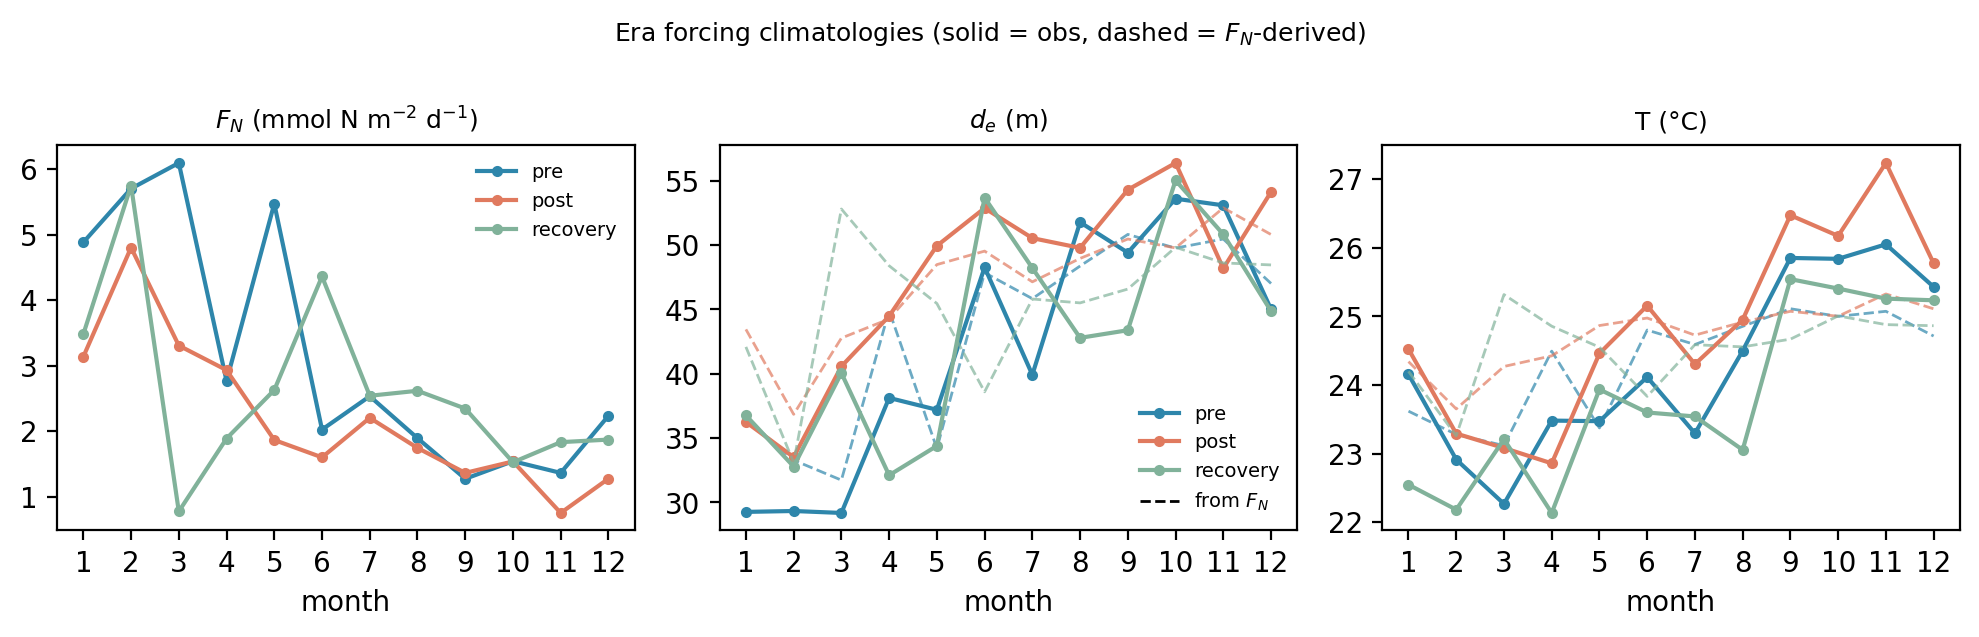

In [4]:
%config InlineBackend.figure_format = 'retina'
# === Era FORCING climatologies: F_N, d_e, T  (+ check vs F_N-derived d_e/T) ===
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from cariaco_obs import DEFAULT_CSV_PATH

FN, DE, TC = 'FN_mmolN_m2_d', 'depth_cutoff', 'Temp_C'
ERA_COL = {'pre':'#2E86AB','post':'#E07A5F','recovery':'#81B29A'}
GROUPS  = {'pre':['pre'], 'post':['post'], 'recovery':['recovery'],
           'pre+recovery':['pre','recovery'], 'post+recovery':['post','recovery']}

df = pd.read_csv(DEFAULT_CSV_PATH, parse_dates=['date'])
df['era'] = np.where(df['date'].dt.year < 2005, 'pre',
            np.where(df['date'].dt.year < 2014, 'post', 'recovery'))
df['mo'] = df['date'].dt.month

# handover regressions (d_e, T derived from F_N)
derive_de = lambda fn: np.clip(55.89 - 3.966*fn, 19, 69)
derive_T  = lambda fn: np.clip(25.64 - 0.414*fn, 22, 29)

def clim(d, col):
    g = d.dropna(subset=[col]).groupby('mo')[col]
    return pd.DataFrame({'mean':g.mean(),'median':g.median(),'n':g.size()}).reindex(range(1,13))

print('=== FORCING CLIMATOLOGIES (monthly, Jan->Dec) ===')
for gname, eras in GROUPS.items():
    d = df[df['era'].isin(eras)]
    cF, cD, cT = clim(d,FN), clim(d,DE), clim(d,TC)
    print(f'\n--- {gname}  (F_N-complete months={int(cF["n"].sum())}) ---')
    print(pd.DataFrame({
        'F_N':cF['mean'].round(2), 'n':cF['n'].astype('Int64'),
        'de_obs':cD['mean'].round(1), 'de_fromFN':derive_de(cF['mean']).round(1),
        'T_obs':cT['mean'].round(2),  'T_fromFN':derive_T(cF['mean']).round(2),
    }).to_string())
    print(f"  annual: F_N={cF['mean'].mean():.2f} | "
          f"de obs={cD['mean'].mean():.1f}/fromFN={derive_de(cF['mean']).mean():.1f} | "
          f"T obs={cT['mean'].mean():.2f}/fromFN={derive_T(cF['mean']).mean():.2f}")

# --- plot forcing cycles (solid=obs, dashed=derived from F_N) ---
fig, axes = plt.subplots(1, 3, figsize=(10, 3.2)); mons = list(range(1,13))
for ax, col, lab in zip(axes, [FN,DE,TC],
                        ['$F_N$ (mmol N m$^{-2}$ d$^{-1}$)','$d_e$ (m)','T (°C)']):
    for g in ['pre','post','recovery']:
        sub = df[df['era'].isin(GROUPS[g])]
        ax.plot(mons, clim(sub,col)['mean'], '-o', ms=3, color=ERA_COL[g], label=g)
        if col in (DE,TC):
            cF = clim(sub,FN)['mean']
            ax.plot(mons, (derive_de(cF) if col==DE else derive_T(cF)),
                    '--', lw=1, color=ERA_COL[g], alpha=0.7)
    ax.set_xlabel('month'); ax.set_title(lab, fontsize=9); ax.set_xticks(mons)
axes[0].legend(frameon=False, fontsize=7)
axes[1].plot([],[], 'k--', lw=1, label='from $F_N$'); axes[1].legend(frameon=False, fontsize=7)
fig.suptitle('Era forcing climatologies (solid = obs, dashed = $F_N$-derived)', fontsize=9)
fig.tight_layout(); plt.show()

=== OBS RESPONSE CLIMATOLOGIES (what the model must hit) ===

--- pre ---
    mcs_um  mcs_med_um  n_size   Pico   Nano  Micro  Zoo>200
mo                                                          
1   13.124      13.267       4  0.308  0.198  0.494    0.055
2   13.029      11.768       4  0.323  0.176  0.500    0.051
3   40.410      40.410       1    NaN    NaN    NaN    0.065
4    9.209      10.195       3  0.300  0.256  0.443    0.065
5    5.477       5.137       3  0.342  0.135  0.524    0.046
6    1.442       1.442       2  0.709  0.223  0.068    0.064
7    8.388       8.727       3  0.277  0.330  0.393    0.045
8    1.180       1.180       1  0.783  0.162  0.055    0.044
9    1.894       1.894       1  0.639  0.245  0.117    0.050
10     NaN         NaN    <NA>    NaN    NaN    NaN    0.075
11   7.200       7.200       2  0.207  0.209  0.584    0.025
12   6.258       6.258       1    NaN    NaN    NaN    0.033
  annual: mcs mean=9.78um med=9.77um | P/N/M=0.43/0.21/0.35 | Zoo>200=0.

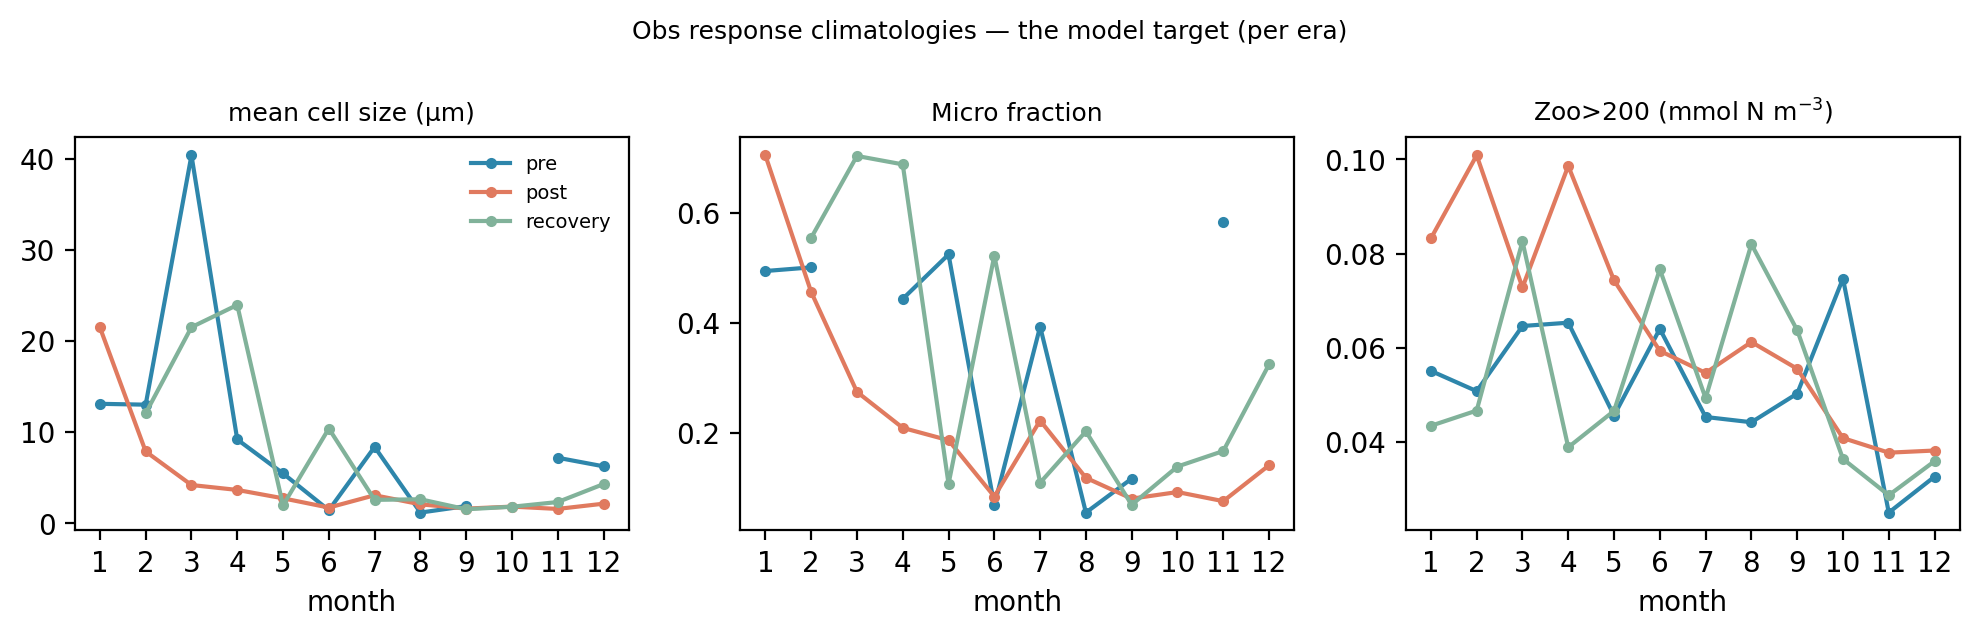

In [5]:
# === Obs RESPONSE climatologies (the model target): mcs, P/N/M, large-Z ===
SIZE, Z200, binc = 'size_centroid', 'zoo_gt200_mmolN', ['pico_mmolN','nano_mmolN','micro_mmolN']

def clim_resp(dd):
    out, cs = {}, dd.dropna(subset=[SIZE]).groupby('mo')[SIZE]
    out['mcs_um']     = (10**cs.mean()).reindex(range(1,13))
    out['mcs_med_um'] = (10**cs.median()).reindex(range(1,13))
    out['n_size']     = cs.size().reindex(range(1,13)).astype('Int64')
    fb = dd.dropna(subset=binc).copy(); t = fb[binc].sum(axis=1)
    for b, c in zip(['Pico','Nano','Micro'], binc):
        fb[b] = fb[c]/t
        out[b] = fb.groupby('mo')[b].mean().reindex(range(1,13))
    out['Zoo>200'] = dd.dropna(subset=[Z200]).groupby('mo')[Z200].mean().reindex(range(1,13))
    return pd.DataFrame(out)

print('=== OBS RESPONSE CLIMATOLOGIES (what the model must hit) ===')
for gname, eras in GROUPS.items():
    R = clim_resp(df[df['era'].isin(eras)])
    print(f'\n--- {gname} ---'); print(R.round(3).to_string())
    print(f"  annual: mcs mean={R['mcs_um'].mean():.2f}um med={R['mcs_med_um'].mean():.2f}um | "
          f"P/N/M={R['Pico'].mean():.2f}/{R['Nano'].mean():.2f}/{R['Micro'].mean():.2f} | "
          f"Zoo>200={R['Zoo>200'].mean():.3f}")

fig, axes = plt.subplots(1, 3, figsize=(10, 3.2)); mons = list(range(1,13))
for ax,(m,lab) in zip(axes, [('mcs_um','mean cell size (µm)'),
                             ('Micro','Micro fraction'),
                             ('Zoo>200','Zoo>200 (mmol N m$^{-3}$)')]):
    for g in ['pre','post','recovery']:
        ax.plot(mons, clim_resp(df[df['era'].isin(GROUPS[g])])[m],
                '-o', ms=3, color=ERA_COL[g], label=g)
    ax.set_xlabel('month'); ax.set_title(lab, fontsize=9); ax.set_xticks(mons)
axes[0].legend(frameon=False, fontsize=7)
fig.suptitle('Obs response climatologies — the model target (per era)', fontsize=9)
fig.tight_layout(); plt.show()

=== model-ready 12-month forcing arrays ===

--- pre ---
     F_N   d_e      T
1   4.88  29.3  24.16
2   5.70  29.3  22.91
3   6.09  29.2  22.27
4   2.77  38.1  23.48
5   5.47  37.2  23.47
6   2.02  48.3  24.12
7   2.53  39.9  23.30
8   1.89  51.8  24.50
9   1.27  49.4  25.85
10  1.54  53.6  25.84
11  1.36  53.1  26.05
12  2.24  45.0  25.43

--- post ---
     F_N   d_e      T
1   3.14  36.3  24.52
2   4.80  33.5  23.29
3   3.31  40.6  23.08
4   2.93  44.5  22.86
5   1.87  49.9  24.46
6   1.60  52.9  25.16
7   2.20  50.5  24.30
8   1.74  49.8  24.95
9   1.36  54.3  26.48
10  1.54  56.4  26.17
11  0.75  48.2  27.24
12  1.28  54.1  25.78

--- recovery ---
     F_N   d_e      T
1   3.48  36.8  22.55
2   5.75  32.8  22.18
3   0.78  40.1  23.21
4   1.89  32.1  22.14
5   2.63  34.4  23.94
6   4.36  53.7  23.60
7   2.54  48.2  23.54
8   2.62  42.8  23.06
9   2.35  43.4  25.54
10  1.53  55.0  25.41
11  1.83  50.8  25.26
12  1.87  44.9  25.24

--- pre+recovery ---
     F_N   d_e      T
1   4.71 

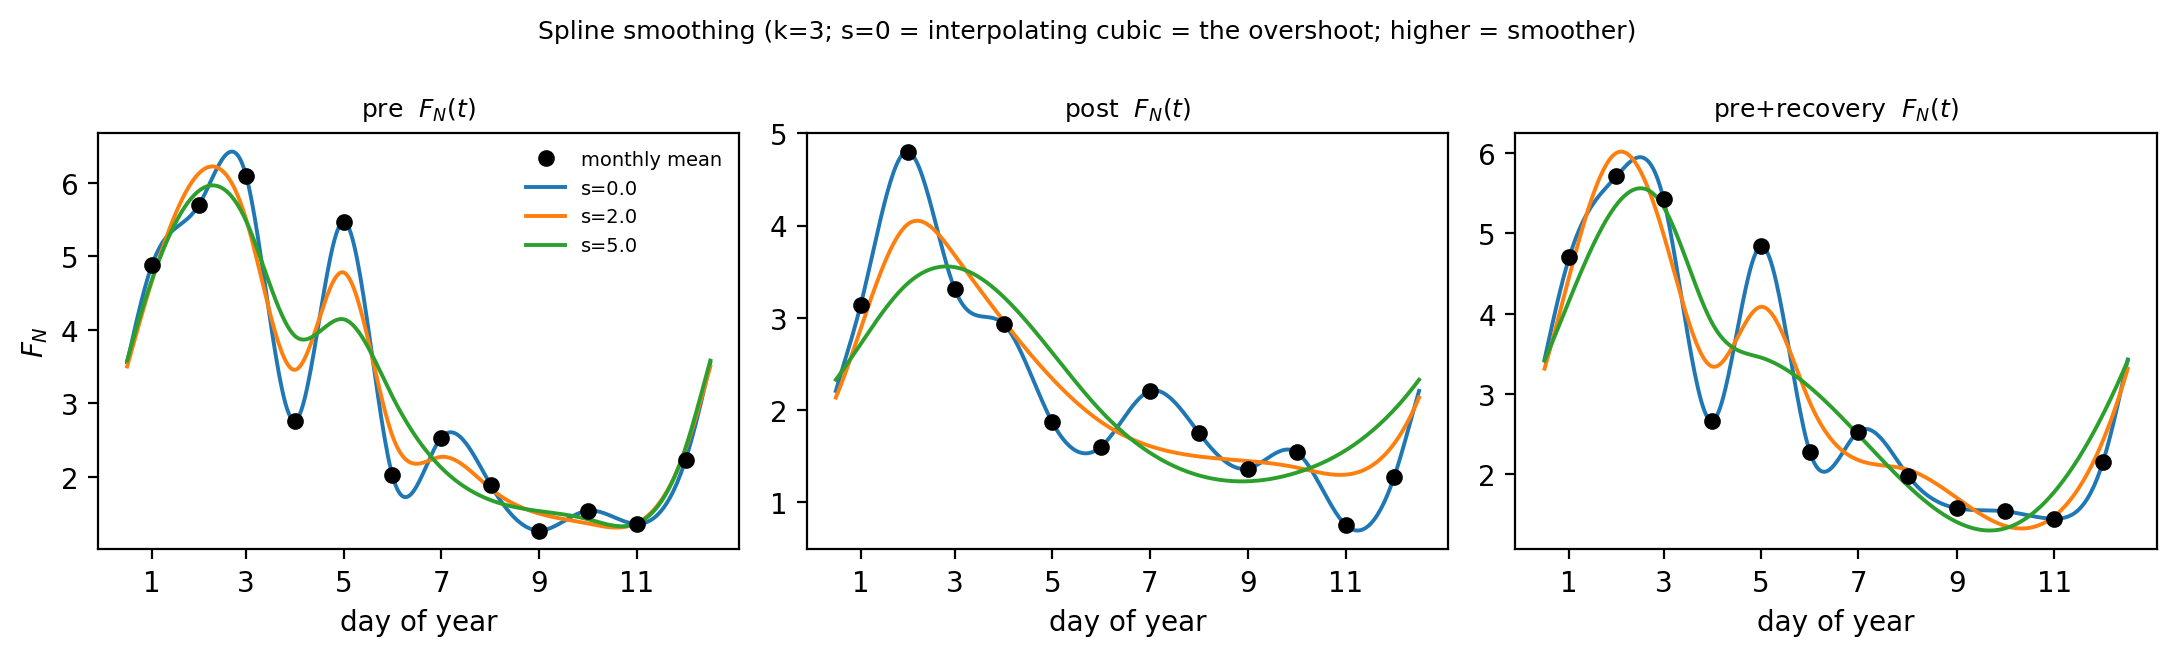


Pick s from the plot (it feeds make_seasonal_input_vars spline_s); same s applies to d_e/T.


In [6]:
# === Step 1: per-era seasonal forcing (F_N, d_e, T) + spline smoothing check ===
import numpy as np, pandas as pd, matplotlib.pyplot as plt
import scipy.interpolate as intrp
from cariaco_obs import DEFAULT_CSV_PATH

FN, DE, TC = 'FN_mmolN_m2_d', 'depth_cutoff', 'Temp_C'
GROUPS = {'pre':['pre'],'post':['post'],'recovery':['recovery'],
          'pre+recovery':['pre','recovery'],'post+recovery':['post','recovery']}
ERA_COL = {'pre':'#2E86AB','post':'#E07A5F','pre+recovery':'#3F51B5'}

df = pd.read_csv(DEFAULT_CSV_PATH, parse_dates=['date'])
df['era'] = np.where(df['date'].dt.year < 2005,'pre',
            np.where(df['date'].dt.year < 2014,'post','recovery'))
df['mo'] = df['date'].dt.month

_DPM = np.array([31,28,31,30,31,30,31,31,30,31,30,31], float)
_MID = np.cumsum(_DPM) - _DPM/2.0; PERIOD = 365.0
def periodic_spline(monthly, k=3, s=0.0, period=PERIOD):     # verbatim comps pattern
    m = np.asarray(monthly, float)
    x = np.concatenate([[0.0], _MID, [period]])
    wrap = (m[0]+m[-1])/2.0; y = np.concatenate([[wrap], m, [wrap]])
    tck = intrp.splrep(x, y, per=True, k=k, s=s)
    return lambda t: np.maximum(intrp.splev(np.mod(t, period), tck, der=0), 0.0)

def monthly_means(eras, col):
    d = df[df['era'].isin(eras)].dropna(subset=[col])
    s = d.groupby('mo')[col].mean().reindex(range(1,13))
    if s.isna().any(): print(f"  [fill] {col} {eras}: months {list(s.index[s.isna()])} interpolated")
    return s.interpolate(limit_direction='both')

FORCING = {}
print('=== model-ready 12-month forcing arrays ===')
for g, eras in GROUPS.items():
    FORCING[g] = {'fn':monthly_means(eras,FN).values,'de':monthly_means(eras,DE).values,
                  't':monthly_means(eras,TC).values}
    print(f"\n--- {g} ---")
    print(pd.DataFrame({'F_N':FORCING[g]['fn'].round(2),'d_e':FORCING[g]['de'].round(1),
                        'T':FORCING[g]['t'].round(2)}, index=range(1,13)).to_string())

# smoothing diagnostic on F_N (the peaky one); d_e/T inherit the same s
tt = np.linspace(0, PERIOD, 366)
fig, axes = plt.subplots(1, 3, figsize=(11, 3.3))
for ax, g in zip(axes, ['pre','post','pre+recovery']):
    ax.plot(_MID, FORCING[g]['fn'], 'ko', ms=5, zorder=5, label='monthly mean')
    for s in [0.0, 2.0, 5.0]:
        ax.plot(tt, periodic_spline(FORCING[g]['fn'], s=s)(tt), lw=1.4, label=f's={s}')
    ax.set_title(f'{g}  $F_N(t)$', fontsize=9); ax.set_xlabel('day of year')
    ax.set_xticks(_MID[::2]); ax.set_xticklabels(range(1,13,2))
axes[0].set_ylabel('$F_N$'); axes[0].legend(fontsize=7, frameon=False)
fig.suptitle('Spline smoothing (k=3; s=0 = interpolating cubic = the overshoot; higher = smoother)', fontsize=9)
fig.tight_layout(); plt.show()
print("\nPick s from the plot (it feeds make_seasonal_input_vars spline_s); same s applies to d_e/T.")

config: 50 yr (spin-up 10) | fish OFF | spline_s=0 | mu_max[0.58,1.76] ks[0.152,4.198] mP=0.02 mZ=0.1
solver_kwargs: {'method': 'RK45', 'atol': 1e-06, 'rtol': 0.0001}
grazing: KsZ=0.23 sigma_log=0.15
[pre+recovery] running 50 yr ...
[post] running 50 yr ...

=== pre+recovery (fish off) ===
     mcs  Pico  Nano  Micro  Z>200  sumP     N
1   4.35  0.50  0.16   0.33  0.010  0.61  0.16
2   6.73  0.46  0.10   0.45  0.049  0.77  0.25
3   8.37  0.42  0.11   0.47  0.073  0.87  0.22
4   7.39  0.44  0.11   0.45  0.046  0.65  0.12
5   7.01  0.44  0.11   0.44  0.023  0.69  0.14
6   7.27  0.43  0.10   0.46  0.029  0.58  0.09
7   5.99  0.46  0.13   0.41  0.016  0.50  0.08
8   5.74  0.45  0.15   0.39  0.009  0.47  0.07
9   5.69  0.46  0.14   0.40  0.006  0.41  0.05
10  5.34  0.46  0.16   0.38  0.004  0.38  0.05
11  4.86  0.47  0.19   0.35  0.003  0.36  0.05
12  4.16  0.49  0.21   0.30  0.002  0.40  0.06
  long-run mean±SD: mcs 6.07±0.71 | Micro 0.40±0.03 | Z>200 0.022±0.003
  Z>200 peak month=0.073 (

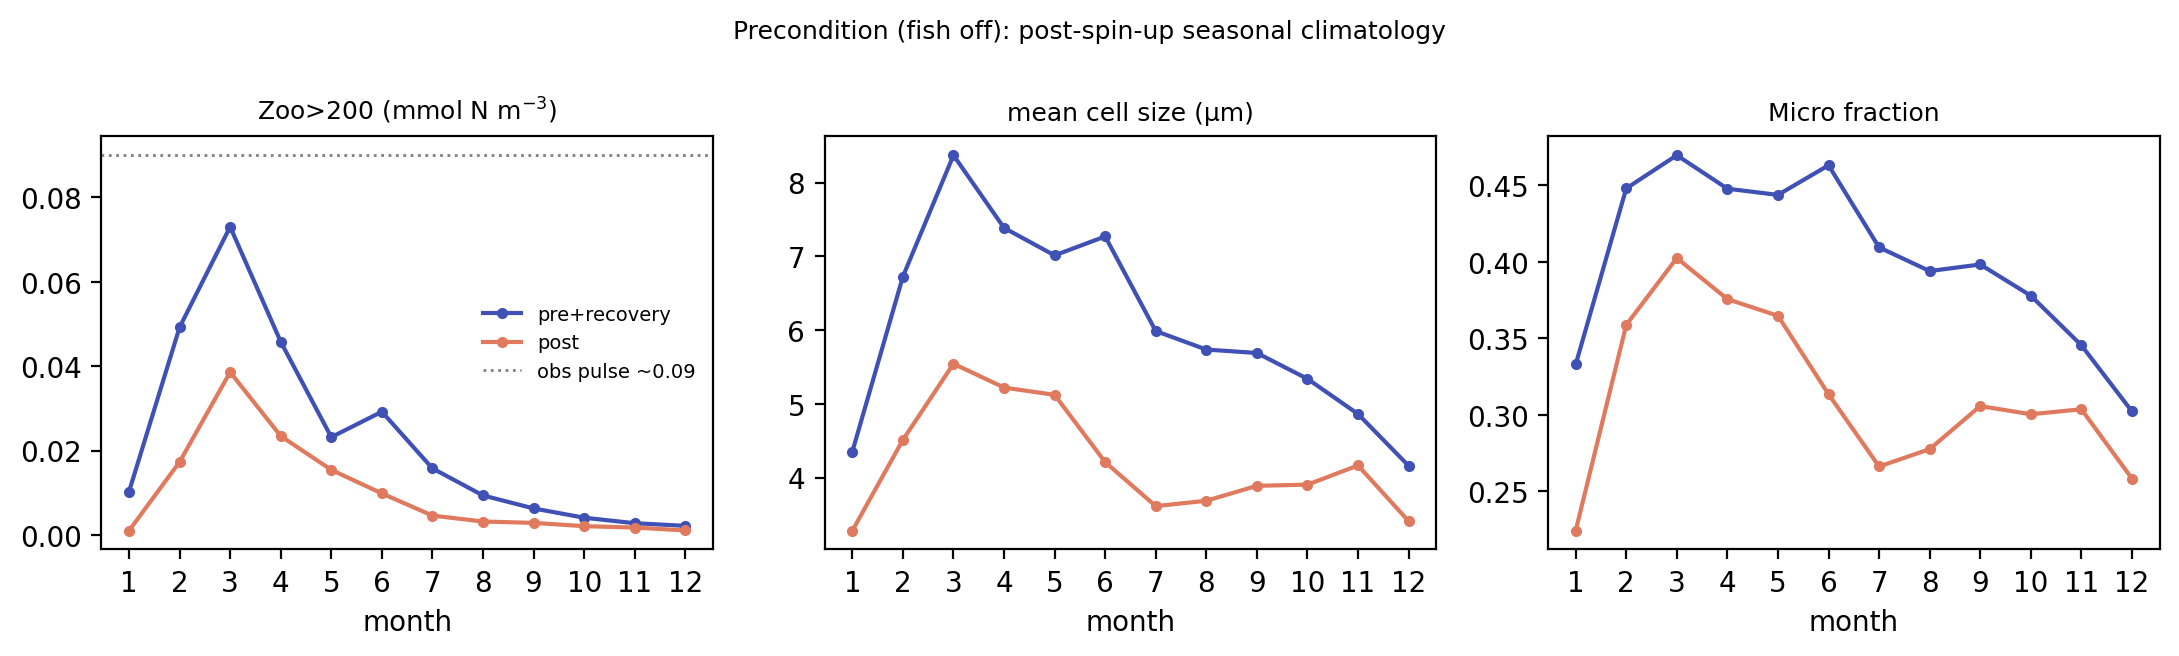

In [7]:
%config InlineBackend.figure_format = 'retina'
# === PRECONDITION: does large Z build under pre+rec vs post forcing? (fish OFF) ===
# Single seasonal IVPs (not a scan). Needs FORCING from the forcing-build cell.
import numpy as np, pandas as pd, xarray as xr, matplotlib.pyplot as plt
import xso, parscan_utils_extended as pue
from baseline_r0_seasonal_setups import (
    model_baseline_seasonal, make_seasonal_input_vars, SLIM_OUTPUT_VARS, IVP_SOLVER_KWARGS)
from baseline_r0_setups import mu_max_arr, ks_arr, M_P, M_Z_BULK

YEARS, SPINUP = 50, 10
RUN_GROUPS = ['pre+recovery', 'post']
GEOM = np.asarray(pue.CARIACO_PHYTO_BIN_GEOMEANS, float)       # [0.63, 6.3, 63] µm
_MEDGES = np.cumsum([31,28,31,30,31,30,31,31,30,31,30,31])     # month day-boundaries
OBS_Z200 = {'pre+recovery': 0.052, 'post': 0.062}; OBS_PULSE = 0.09  # obs anchors (net-tow)

time = np.arange(0.0, YEARS*365.0 + 1.0, 1.0)
print(f"config: {YEARS} yr (spin-up {SPINUP}) | fish OFF | spline_s=0 | "
      f"mu_max[{mu_max_arr.min():.2f},{mu_max_arr.max():.2f}] "
      f"ks[{ks_arr.min():.3f},{ks_arr.max():.3f}] mP={M_P} mZ={M_Z_BULK}")
print(f"solver_kwargs: {IVP_SOLVER_KWARGS}")

def reduce_run(out):
    pb, zb = out['Phytoplankton__biomass'], out['Zooplankton__biomass']
    pdim = [d for d in pb.dims if d != 'time'][0]; zdim = [d for d in zb.dims if d != 'time'][0]
    pe, ze = out[pdim].values, out[zdim].values
    P = pb.transpose(pdim, 'time').values; Z = zb.transpose(zdim, 'time').values
    W = pue.compute_sieburth_weights(pe); bins = W @ P; sb = bins.sum(0)
    fr = np.divide(bins, sb, out=np.full_like(bins, np.nan), where=sb > 0)
    return dict(t=out['time'].values, sumP=P.sum(0), mcs=10**(np.log10(GEOM) @ fr),
                pico=fr[0], nano=fr[1], micro=fr[2],
                Z200=Z[ze > 200].sum(0), Z500=Z[ze > 500].sum(0),
                N=out['Nutrient__value'].values)

def clim_and_stats(r):
    keep = r['t'] >= SPINUP*365.0
    mo = np.clip(np.searchsorted(_MEDGES, np.mod(r['t'][keep], 365.0), 'right') + 1, 1, 12)
    yr = (r['t'][keep] // 365.0).astype(int); ys = np.unique(yr); half = len(ys)//2
    s = {}
    for k in ['mcs','pico','nano','micro','Z200','Z500','sumP','N']:
        v = r[k][keep]
        s[k] = np.array([np.nanmean(v[mo == m]) if np.any(mo == m) else np.nan for m in range(1,13)])
        ann = np.array([np.nanmean(v[yr == y]) for y in ys])
        s[k+'_mean'], s[k+'_sd'] = float(np.nanmean(ann)), float(np.nanstd(ann))
    sp = r['sumP'][keep]
    s['cv_sumP'] = float(np.nanstd(sp)/max(np.nanmean(sp), 1e-12))
    s['has_nan'] = bool(np.isnan(sp).any() or np.isnan(r['Z200'][keep]).any())
    am = np.array([np.nanmean(r['mcs'][keep][yr == y]) for y in ys])
    s['mcs_conv'] = float(np.nanmean(am[half:]) / max(np.nanmean(am[:half]), 1e-12))
    return s

RES = {}
for g in RUN_GROUPS:
    iv = make_seasonal_input_vars(FORCING[g]['fn'], FORCING[g]['de'], FORCING[g]['t'],
                                  fish_rate=0.0, spline_s=0.0)
    if g == RUN_GROUPS[0]:
        print(f"grazing: KsZ={iv['Grazing'].get('KsZ')} sigma_log={iv['Grazing'].get('sigma_log')}")
    setup = xso.setup(solver='solve_ivp', model=model_baseline_seasonal, time=time,
                      input_vars=iv, output_vars=SLIM_OUTPUT_VARS, solver_kwargs=IVP_SOLVER_KWARGS)
    print(f"[{g}] running {YEARS} yr ...", flush=True)
    RES[g] = clim_and_stats(reduce_run(pue.run_single_point(model_baseline_seasonal, setup, {})))

for g in RUN_GROUPS:
    s = RES[g]
    print(f"\n=== {g} (fish off) ===")
    print(pd.DataFrame({'mcs':s['mcs'].round(2),'Pico':s['pico'].round(2),'Nano':s['nano'].round(2),
        'Micro':s['micro'].round(2),'Z>200':s['Z200'].round(3),'sumP':s['sumP'].round(2),
        'N':s['N'].round(2)}, index=range(1,13)).to_string())
    print(f"  long-run mean±SD: mcs {s['mcs_mean']:.2f}±{s['mcs_sd']:.2f} | "
          f"Micro {s['micro_mean']:.2f}±{s['micro_sd']:.2f} | Z>200 {s['Z200_mean']:.3f}±{s['Z200_sd']:.3f}")
    print(f"  Z>200 peak month={np.nanmax(s['Z200']):.3f} (obs pulse ~{OBS_PULSE}) | "
          f"annual {s['Z200_mean']:.3f} (obs ~{OBS_Z200[g]})")
    print(f"  health: cv_sumP={s['cv_sumP']:.3f} has_nan={s['has_nan']} mcs_conv(2nd/1st)={s['mcs_conv']:.2f}")
print(f"\nPRECONDITION read: Z>200 peak pre+rec={np.nanmax(RES['pre+recovery']['Z200']):.3f} "
      f"vs post={np.nanmax(RES['post']['Z200']):.3f}  "
      f"-> {'pulse builds, supply-gated (pre>post)' if np.nanmax(RES['pre+recovery']['Z200'])>np.nanmax(RES['post']['Z200']) else 'CHECK: not larger under pre'}")

COL = {'pre+recovery':'#3F51B5','post':'#E07A5F'}
fig, axes = plt.subplots(1, 3, figsize=(11, 3.3)); mons = range(1,13)
for ax,(k,lab) in zip(axes, [('Z200','Zoo>200 (mmol N m$^{-3}$)'),
                             ('mcs','mean cell size (µm)'),('micro','Micro fraction')]):
    for g in RUN_GROUPS: ax.plot(mons, RES[g][k], '-o', ms=3, color=COL[g], label=g)
    ax.set_xlabel('month'); ax.set_title(lab, fontsize=9); ax.set_xticks(mons)
    if k == 'Z200': ax.axhline(OBS_PULSE, color='0.5', ls=':', lw=1, label='obs pulse ~0.09')
axes[0].legend(fontsize=7, frameon=False)
fig.suptitle('Precondition (fish off): post-spin-up seasonal climatology', fontsize=9)
fig.tight_layout(); plt.show()

In [8]:
# === QUICK TEST SCAN (smoke test: wiring + meaningful output) ===
import numpy as np, seasonal_scan_harness as ssh

res = ssh.run_seasonal_scan(
    constructs=['taniguchi', 'maranon_ward'],   # 2 allometries -> must differ
    groups=['pre+recovery', 'post'],            # 2 forcings
    fish_rates=[0.0, 0.5],                       # fish off + one on -> must differ
    years=20, spinup=5,                          # short: smoke test, not final
    save_path='seasonal_scan_TEST.pkl')

print("\n=== TEST table ===")
print(res.table().round(3).to_string(index=False))
print("\n=== TEST fish effect (on - off) ===")
print(res.fish_effect().round(3).to_string(index=False))

[seasonal scan] 8 runs: ['taniguchi', 'maranon_ward'] x ['pre+recovery', 'post'] x fish=[0.0, 0.5] | 20 yr each (spin-up 5)
solver: {'method': 'RK45', 'atol': 1e-06, 'rtol': 0.0001} | spline_s=0.0 | grazing_override=None
   1/8 taniguchi     pre+recovery  fish=0     mcs= 5.76 micro=0.39 Z200pk=0.068 conv=0.99 nan=False score= 0.19 |  0.2m ETA  1.2m
   2/8 taniguchi     pre+recovery  fish=0.5   mcs= 6.01 micro=0.32 Z200pk=0.027 conv=1.01 nan=False score= 0.08 |  0.3m ETA  1.0m
   3/8 taniguchi     post          fish=0     mcs= 4.14 micro=0.31 Z200pk=0.040 conv=1.04 nan=False score= 0.41 |  0.5m ETA  0.8m
   4/8 taniguchi     post          fish=0.5   mcs= 3.71 micro=0.22 Z200pk=0.011 conv=0.98 nan=False score= 0.18 |  0.6m ETA  0.6m
   5/8 maranon_ward  pre+recovery  fish=0     mcs= 3.20 micro=0.19 Z200pk=0.121 conv=1.02 nan=False score= 0.35 |  0.7m ETA  0.4m


/Users/aoop/Documents/GitHub/Research/xarray-simlab-ode/src/xso/core.py:148: UserWarning: Instability event triggered at t=743.7 on Grazing_grazing[65,39] = -1.04e-06. Run terminated, remaining time points NaN-padded. To loosen the safety threshold pass solver_kwargs={'instability_neg_threshold': -1e-3} to xso.setup; to disable, pass float('-inf').
  self.solver.solve(self.model, time_step)


   6/8 maranon_ward  pre+recovery  fish=0.5   mcs=  nan micro= nan Z200pk=  nan conv= nan nan=True score=  nan |  0.7m ETA  0.2m


/Users/aoop/Documents/GitHub/Research/SSMCariaco/parameter_scan/seasonal_scan_harness.py:150: RuntimeWarning: Mean of empty slice
  s['clim_' + k] = np.array([np.nanmean(v[mo == m]) if np.any(mo == m) else np.nan
/Users/aoop/Documents/GitHub/Research/SSMCariaco/parameter_scan/seasonal_scan_harness.py:152: RuntimeWarning: Mean of empty slice
  ann = np.array([np.nanmean(v[yr == y]) for y in ys])
/Users/aoop/Documents/GitHub/Research/SSMCariaco/parameter_scan/seasonal_scan_harness.py:153: RuntimeWarning: Mean of empty slice
  s[k] = float(np.nanmean(ann))
/Users/aoop/mambaforge/envs/MS3_3/lib/python3.14/site-packages/numpy/lib/_nanfunctions_impl.py:1997: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/Users/aoop/Documents/GitHub/Research/SSMCariaco/parameter_scan/seasonal_scan_harness.py:155: RuntimeWarning: All-NaN slice encountered
  s['Z200_peak'] = float(np.nanmax(s['clim_Z200']))
/Users/aoop/Documents/GitHub/Research/

   7/8 maranon_ward  post          fish=0     mcs= 2.39 micro=0.15 Z200pk=0.084 conv=1.00 nan=False score= 0.15 |  0.8m ETA  0.1m
   8/8 maranon_ward  post          fish=0.5   mcs= 4.18 micro=0.21 Z200pk=0.032 conv=0.77 nan=False score= 0.26 |  0.9m ETA  0.0m

=== TEST table ===
   construct        group  fish   mcs  micro  pico  nano  Z200  Z200_peak  cv_sumP  mcs_conv  has_nan  score  obs_mcs  obs_micro  obs_Z200
   taniguchi pre+recovery   0.5 6.012  0.316 0.482 0.202 0.007      0.027    0.558     1.014    False  0.077    5.941      0.346     0.050
maranon_ward         post   0.0 2.385  0.146 0.587 0.267 0.024      0.084    0.322     0.999    False  0.154    2.811      0.196     0.065
   taniguchi         post   0.5 3.713  0.223 0.504 0.273 0.002      0.011    0.356     0.977    False  0.182    2.811      0.196     0.065
   taniguchi pre+recovery   0.0 5.760  0.390 0.466 0.143 0.023      0.068    0.339     0.990    False  0.185    5.941      0.346     0.050
maranon_ward         post

In [9]:
import importlib, numpy as np, pandas as pd, seasonal_scan_harness as ssh
importlib.reload(ssh)   # or restart kernel + re-import

res = ssh.run_seasonal_scan(
    constructs=['taniguchi', 'maranon_ward'], groups=['pre+recovery', 'post'],
    fish_rates=[0.0, 0.5], years=40, spinup=10, save_path='seasonal_scan_TEST.pkl')
print(res.table().round(3).to_string(index=False))
print("\n", res.fish_effect().round(3).to_string(index=False))

[seasonal scan] 8 runs: ['taniguchi', 'maranon_ward'] x ['pre+recovery', 'post'] x fish=[0.0, 0.5] | 40 yr each (spin-up 10)
solver: {'method': 'RK45', 'atol': 1e-06, 'rtol': 0.0001, 'instability_neg_threshold': -0.001} | spline_s=0.0 | grazing_override=None
   1/8 taniguchi     pre+recovery  fish=0     mcs= 6.09 micro=0.40 Z200pk=0.075 conv=1.06 nan=False score= 0.32 |  0.3m ETA  2.4m
   2/8 taniguchi     pre+recovery  fish=0.5   mcs= 6.43 micro=0.32 Z200pk=0.023 conv=1.00 nan=False score= 0.20 |  0.7m ETA  2.1m
   3/8 taniguchi     post          fish=0     mcs= 4.22 micro=0.31 Z200pk=0.037 conv=1.01 nan=False score= 0.87 |  1.0m ETA  1.6m
   4/8 taniguchi     post          fish=0.5   mcs= 3.75 micro=0.22 Z200pk=0.014 conv=1.01 nan=False score= 0.50 |  1.3m ETA  1.3m
   5/8 maranon_ward  pre+recovery  fish=0     mcs= 3.32 micro=0.20 Z200pk=0.129 conv=1.01 nan=False score= 0.27 |  1.5m ETA  0.9m


/Users/aoop/Documents/GitHub/Research/xarray-simlab-ode/src/xso/core.py:148: UserWarning: Instability event triggered at t=5939 on Z[5] = -0.00164. Run terminated, remaining time points NaN-padded. To loosen the safety threshold pass solver_kwargs={'instability_neg_threshold': -1e-3} to xso.setup; to disable, pass float('-inf').
  self.solver.solve(self.model, time_step)


   6/8 maranon_ward  pre+recovery  fish=0.5   mcs= 8.10 micro=0.32 Z200pk=0.048 conv= nan nan=True score= 0.35 |  1.6m ETA  0.5m


/Users/aoop/Documents/GitHub/Research/SSMCariaco/parameter_scan/seasonal_scan_harness.py:175: RuntimeWarning: Mean of empty slice
  input_vars=iv, output_vars=SLIM_OUTPUT_VARS, solver_kwargs=solver_kwargs)
/Users/aoop/Documents/GitHub/Research/SSMCariaco/parameter_scan/seasonal_scan_harness.py:182: RuntimeWarning: Mean of empty slice
  # =============================================================================
/Users/aoop/Documents/GitHub/Research/SSMCariaco/parameter_scan/seasonal_scan_harness.py:183: RuntimeWarning: Mean of empty slice
  def score(metrics, obs, weights=None):


   7/8 maranon_ward  post          fish=0     mcs= 2.34 micro=0.14 Z200pk=0.093 conv=0.97 nan=False score= 0.07 |  1.7m ETA  0.2m
   8/8 maranon_ward  post          fish=0.5   mcs= 4.36 micro=0.22 Z200pk=0.029 conv=1.05 nan=False score= 0.59 |  1.9m ETA  0.0m
   construct        group  fish  score   mcs  obs_mcs  micro  obs_micro  pico  obs_pico  nano  obs_nano  sumP  obs_sumP     N  obs_N    PP  obs_PP  Export  obs_Export  Z200  obs_Z200  Z500  obs_Z500  Z200_peak  cv_sumP  mcs_conv  has_nan
maranon_ward         post   0.0  0.068 2.342    2.297  0.141      0.125 0.590     0.564 0.269     0.264 0.524     0.460 0.425  1.090 0.118   0.202   0.048       2.238 0.025     0.055 0.002     0.033      0.093    0.318     0.972    False
   taniguchi pre+recovery   0.5  0.197 6.425    4.841  0.321      0.271 0.477     0.429 0.202     0.205 0.579     0.535 0.098  1.196 0.173   0.286   0.072       2.675 0.007     0.047 0.000     0.024      0.023    0.560     0.996    False
maranon_ward pre+recovery 

In [10]:
import importlib, numpy as np, pandas as pd, seasonal_scan_harness as ssh
importlib.reload(ssh)

res = ssh.run_seasonal_scan(
    constructs=['taniguchi', 'maranon_ward', 'banas'],
    groups=['pre+recovery', 'post', 'recovery'],
    fish_rates=np.round(np.linspace(0.0, 1.0, 5), 3),
    years=80, spinup=15, save_path='seasonal_scan_results.pkl')
print(res.table().round(3).to_string(index=False))
print("\n", res.fish_effect().round(3).to_string(index=False))

[seasonal scan] 45 runs: ['taniguchi', 'maranon_ward', 'banas'] x ['pre+recovery', 'post', 'recovery'] x fish=[np.float64(0.0), np.float64(0.25), np.float64(0.5), np.float64(0.75), np.float64(1.0)] | 80 yr each (spin-up 15)
solver: {'method': 'RK45', 'atol': 1e-06, 'rtol': 0.0001, 'instability_neg_threshold': -0.001} | spline_s=0.0 | grazing_override=None
   1/45 taniguchi     pre+recovery  fish=0     mcs= 6.03 micro=0.40 Z200pk=0.068 conv=0.98 nan=False score= 0.31 |  0.7m ETA 31.4m
   2/45 taniguchi     pre+recovery  fish=0.25  mcs= 6.00 micro=0.33 Z200pk=0.053 conv=0.98 nan=False score= 0.18 |  1.4m ETA 30.5m
   3/45 taniguchi     pre+recovery  fish=0.5   mcs= 6.31 micro=0.31 Z200pk=0.024 conv=0.97 nan=False score= 0.18 |  2.1m ETA 29.8m
   4/45 taniguchi     pre+recovery  fish=0.75  mcs= 6.81 micro=0.32 Z200pk=0.020 conv=1.03 nan=False score= 0.24 |  2.8m ETA 28.8m
   5/45 taniguchi     pre+recovery  fish=1     mcs= 5.17 micro=0.28 Z200pk=0.014 conv=0.95 nan=False score= 0.16 |  3.

/Users/aoop/Documents/GitHub/Research/xarray-simlab-ode/src/xso/core.py:148: UserWarning: Instability event triggered at t=1.716e+04 on P[17] = -0.00149. Run terminated, remaining time points NaN-padded. To loosen the safety threshold pass solver_kwargs={'instability_neg_threshold': -1e-3} to xso.setup; to disable, pass float('-inf').
  self.solver.solve(self.model, time_step)


  17/45 maranon_ward  pre+recovery  fish=0.25  mcs= 4.58 micro=0.23 Z200pk=0.105 conv=0.59 nan=True score= 0.17 | 10.7m ETA 17.7m


/Users/aoop/Documents/GitHub/Research/SSMCariaco/parameter_scan/seasonal_scan_harness.py:175: RuntimeWarning: Mean of empty slice
  input_vars=iv, output_vars=SLIM_OUTPUT_VARS, solver_kwargs=solver_kwargs)
/Users/aoop/Documents/GitHub/Research/SSMCariaco/parameter_scan/seasonal_scan_harness.py:182: RuntimeWarning: Mean of empty slice
  # =============================================================================
/Users/aoop/Documents/GitHub/Research/xarray-simlab-ode/src/xso/core.py:148: UserWarning: Instability event triggered at t=5939 on Z[5] = -0.00164. Run terminated, remaining time points NaN-padded. To loosen the safety threshold pass solver_kwargs={'instability_neg_threshold': -1e-3} to xso.setup; to disable, pass float('-inf').
  self.solver.solve(self.model, time_step)


  18/45 maranon_ward  pre+recovery  fish=0.5   mcs= 9.36 micro=0.36 Z200pk=0.069 conv= nan nan=True score= 0.50 | 10.8m ETA 16.3m


...

/Users/aoop/Documents/GitHub/Research/SSMCariaco/parameter_scan/seasonal_scan_harness.py:173: RuntimeWarning: Mean of empty slice
  time_ax = np.arange(0.0, years * 365.0 + 1.0, 1.0)
/Users/aoop/Documents/GitHub/Research/SSMCariaco/parameter_scan/seasonal_scan_harness.py:175: RuntimeWarning: Mean of empty slice
  input_vars=iv, output_vars=SLIM_OUTPUT_VARS, solver_kwargs=solver_kwargs)
/Users/aoop/Documents/GitHub/Research/SSMCariaco/parameter_scan/seasonal_scan_harness.py:176: RuntimeWarning: Mean of empty slice
  out = pue.run_single_point(model_baseline_seasonal, setup, {})
/Users/aoop/mambaforge/envs/MS3_3/lib/python3.14/site-packages/numpy/lib/_nanfunctions_impl.py:1997: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/Users/aoop/Documents/GitHub/Research/SSMCariaco/parameter_scan/seasonal_scan_harness.py:178: RuntimeWarning: All-NaN slice encountered
  
/Users/aoop/Documents/GitHub/Research/SSMCariaco/parameter_scan

  20/45 maranon_ward  pre+recovery  fish=1     mcs= 8.52 micro=0.31 Z200pk=0.034 conv= nan nan=True score= 0.43 | 11.3m ETA 14.1m


/Users/aoop/Documents/GitHub/Research/SSMCariaco/parameter_scan/seasonal_scan_harness.py:175: RuntimeWarning: Mean of empty slice
  input_vars=iv, output_vars=SLIM_OUTPUT_VARS, solver_kwargs=solver_kwargs)
/Users/aoop/Documents/GitHub/Research/SSMCariaco/parameter_scan/seasonal_scan_harness.py:182: RuntimeWarning: Mean of empty slice
  # =============================================================================
/Users/aoop/Documents/GitHub/Research/SSMCariaco/parameter_scan/seasonal_scan_harness.py:183: RuntimeWarning: Mean of empty slice
  def score(metrics, obs, weights=None):


  21/45 maranon_ward  post          fish=0     mcs= 2.32 micro=0.14 Z200pk=0.092 conv=1.01 nan=False score= 0.06 | 11.6m ETA 13.3m


KeyboardInterrupt: 

In [12]:
import importlib, numpy as np, pandas as pd, seasonal_scan_harness as ssh
importlib.reload(ssh)
res = ssh.run_seasonal_scan(constructs=['taniguchi','maranon_ward'],
    groups=['pre+recovery','post'], fish_rates=[0.0, 0.5],
    years=40, spinup=10, save_path='seasonal_scan_TEST.pkl')
print(res.table().round(3).to_string(index=False))
print("\nExport (model mean/med vs obs):")
print(res.compare('Export').round(3).to_string(index=False))

[seasonal scan] 8 runs: ['taniguchi', 'maranon_ward'] x ['pre+recovery', 'post'] x fish=[0.0, 0.5] x params[] | 40 yr each (spin-up 10)
solver: {'method': 'RK45', 'atol': 1e-06, 'rtol': 0.0001, 'instability_neg_threshold': -0.001} | spline_s=0.0
    1/8 taniguchi     pre+recovery  fish=0    {} mcs= 6.09/ 5.14 micro=0.40 Z200pk=0.075 conv=1.06 nan=False score= 0.26 |  0.3m ETA  2.4m
    2/8 taniguchi     pre+recovery  fish=0.5  {} mcs= 6.42/ 3.40 micro=0.32 Z200pk=0.023 conv=1.00 nan=False score= 0.18 |  0.7m ETA  2.0m
    3/8 taniguchi     post          fish=0    {} mcs= 4.22/ 3.81 micro=0.31 Z200pk=0.037 conv=1.01 nan=False score= 0.78 |  1.0m ETA  1.6m
    4/8 taniguchi     post          fish=0.5  {} mcs= 3.75/ 2.86 micro=0.22 Z200pk=0.014 conv=1.01 nan=False score= 0.24 |  1.3m ETA  1.3m
    5/8 maranon_ward  pre+recovery  fish=0    {} mcs= 3.32/ 2.41 micro=0.20 Z200pk=0.129 conv=1.01 nan=False score= 0.40 |  1.4m ETA  0.9m


/Users/aoop/Documents/GitHub/Research/xarray-simlab-ode/src/xso/core.py:148: UserWarning: Instability event triggered at t=5939 on Z[5] = -0.00164. Run terminated, remaining time points NaN-padded. To loosen the safety threshold pass solver_kwargs={'instability_neg_threshold': -1e-3} to xso.setup; to disable, pass float('-inf').
  self.solver.solve(self.model, time_step)


    6/8 maranon_ward  pre+recovery  fish=0.5  {} mcs=  nan/  nan micro= nan Z200pk=  nan conv= nan nan=True score=  nan |  1.5m ETA  0.5m
    7/8 maranon_ward  post          fish=0    {} mcs= 2.34/ 2.08 micro=0.14 Z200pk=0.093 conv=0.97 nan=False score= 0.30 |  1.7m ETA  0.2m
    8/8 maranon_ward  post          fish=0.5  {} mcs= 4.36/ 2.88 micro=0.22 Z200pk=0.029 conv=1.05 nan=False score= 0.25 |  1.9m ETA  0.0m
   construct        group  fish  score  score_mean  score_med   mcs  mcs_med  micro  micro_med     N  Z200_peak  cv_sumP  mcs_conv  has_nan
   taniguchi pre+recovery   0.5  0.178       0.145      0.178 6.425    3.402  0.321      0.247 0.098      0.023    0.560     0.996    False
   taniguchi         post   0.5  0.242       0.142      0.242 3.749    2.856  0.221      0.176 0.067      0.014    0.357     1.010    False
maranon_ward         post   0.5  0.251       0.111      0.251 4.356    2.876  0.218      0.176 0.307      0.029    0.557     1.053    False
   taniguchi pre+recover

In [ ]:
import importlib, numpy as np, pandas as pd, seasonal_scan_harness as ssh
importlib.reload(ssh)

res = ssh.run_seasonal_scan(
    constructs=['taniguchi', 'maranon_ward', 'banas'],   # growth
    groups=['pre+recovery', 'post', 'recovery'],          # bottom-up
    fish_rates=np.round(np.linspace(0.0, 1.0, 5), 3),     # top-down (r_F, still uncalibrated)
    param_grid={'mP': [0.02, 0.05], 'sigma_log': [0.15, 0.20]},
    years=60, spinup=15,
    save_path='seasonal_scan_results.pkl')

print(res.table().round(3).to_string(index=False))
print("\n", res.fish_effect().round(3).to_string(index=False))
# add 'KsZ': [0.20, 0.23] to param_grid to double it if you want the grazing-affinity axis too

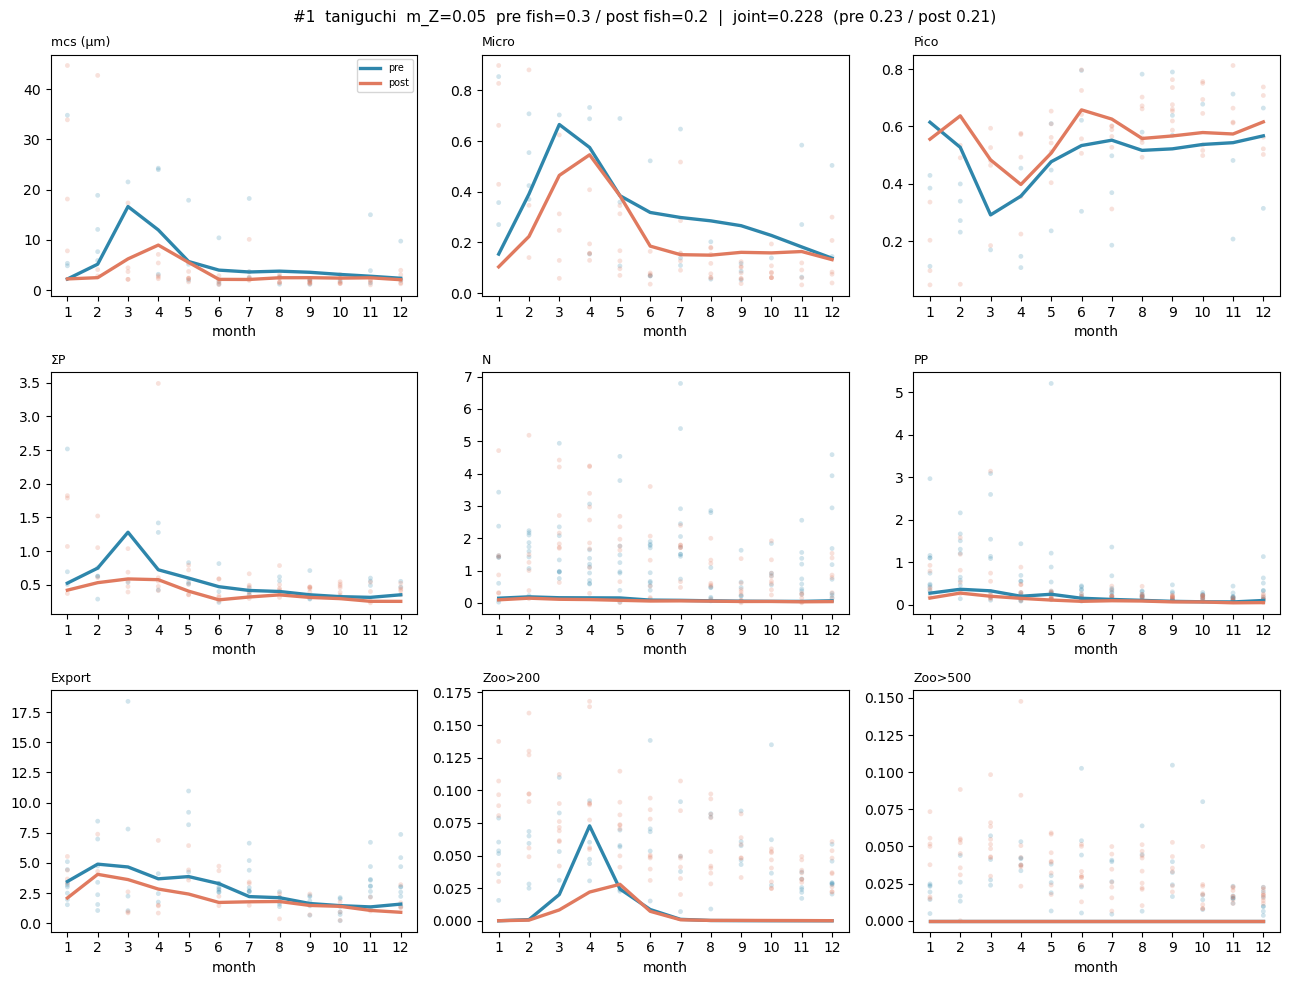

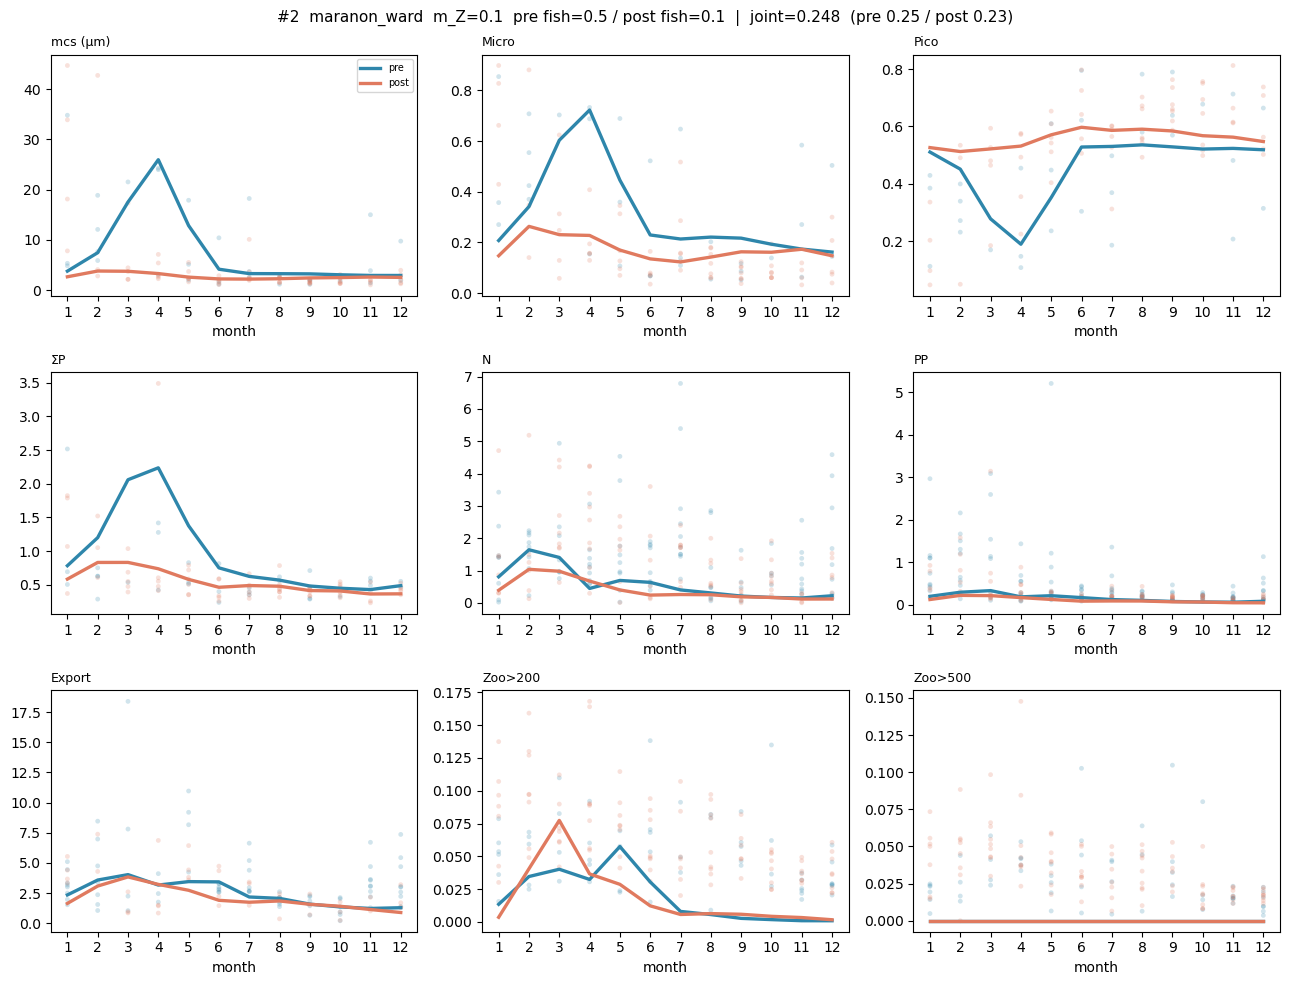

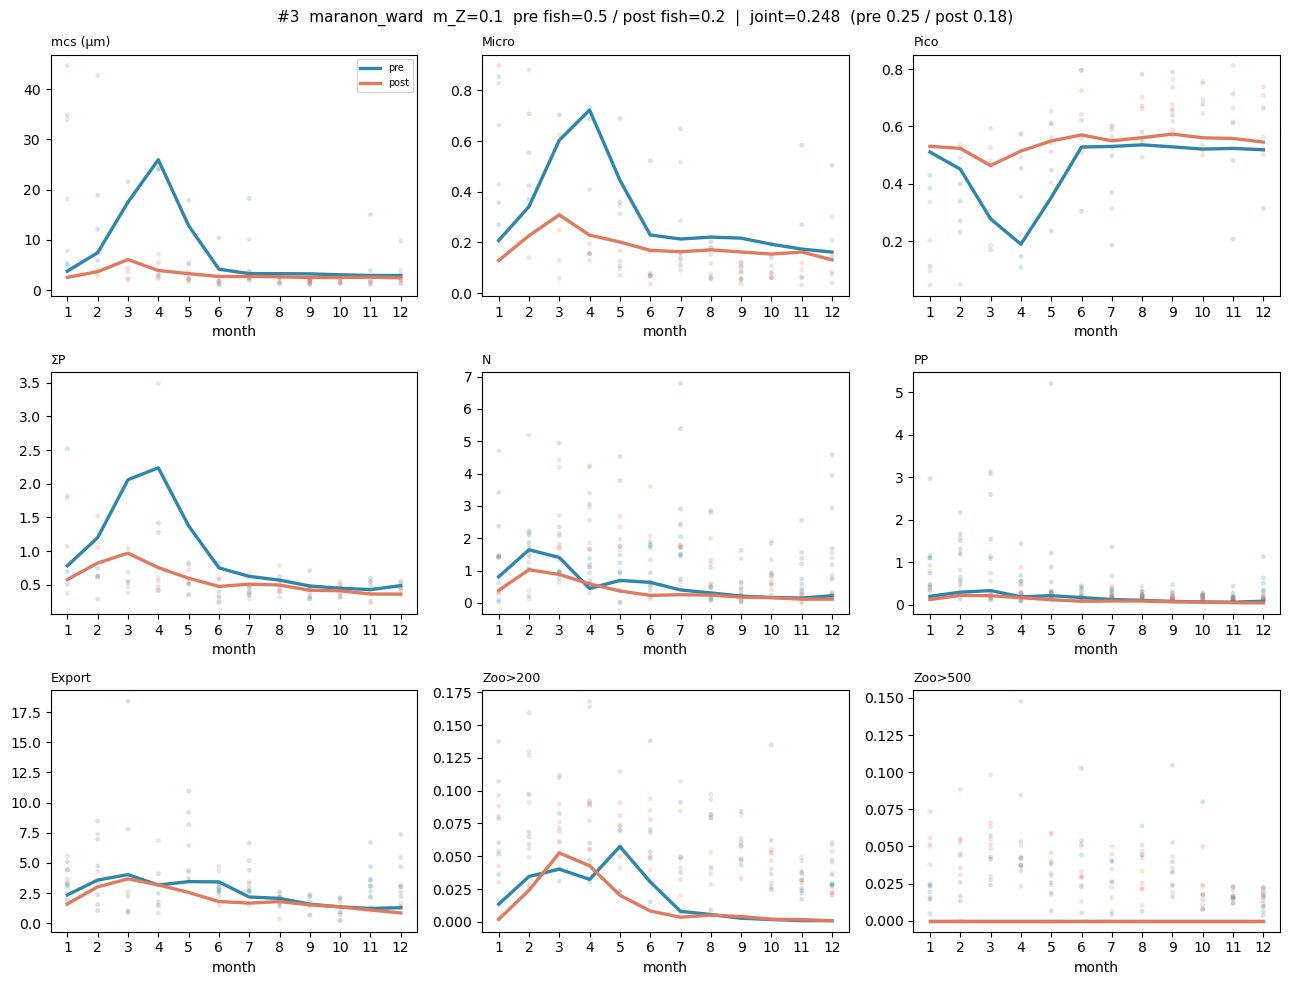

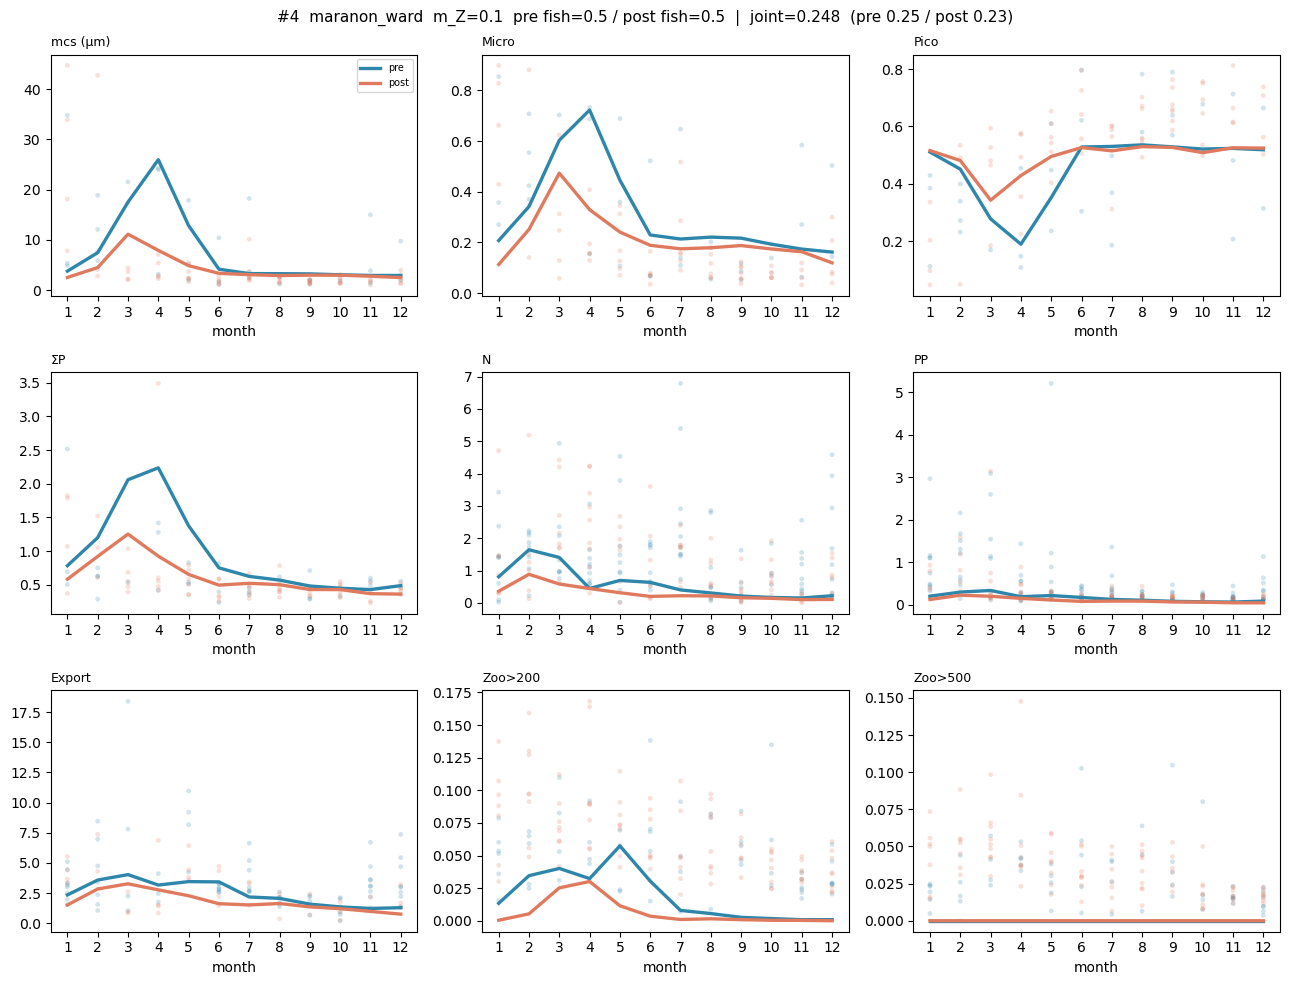

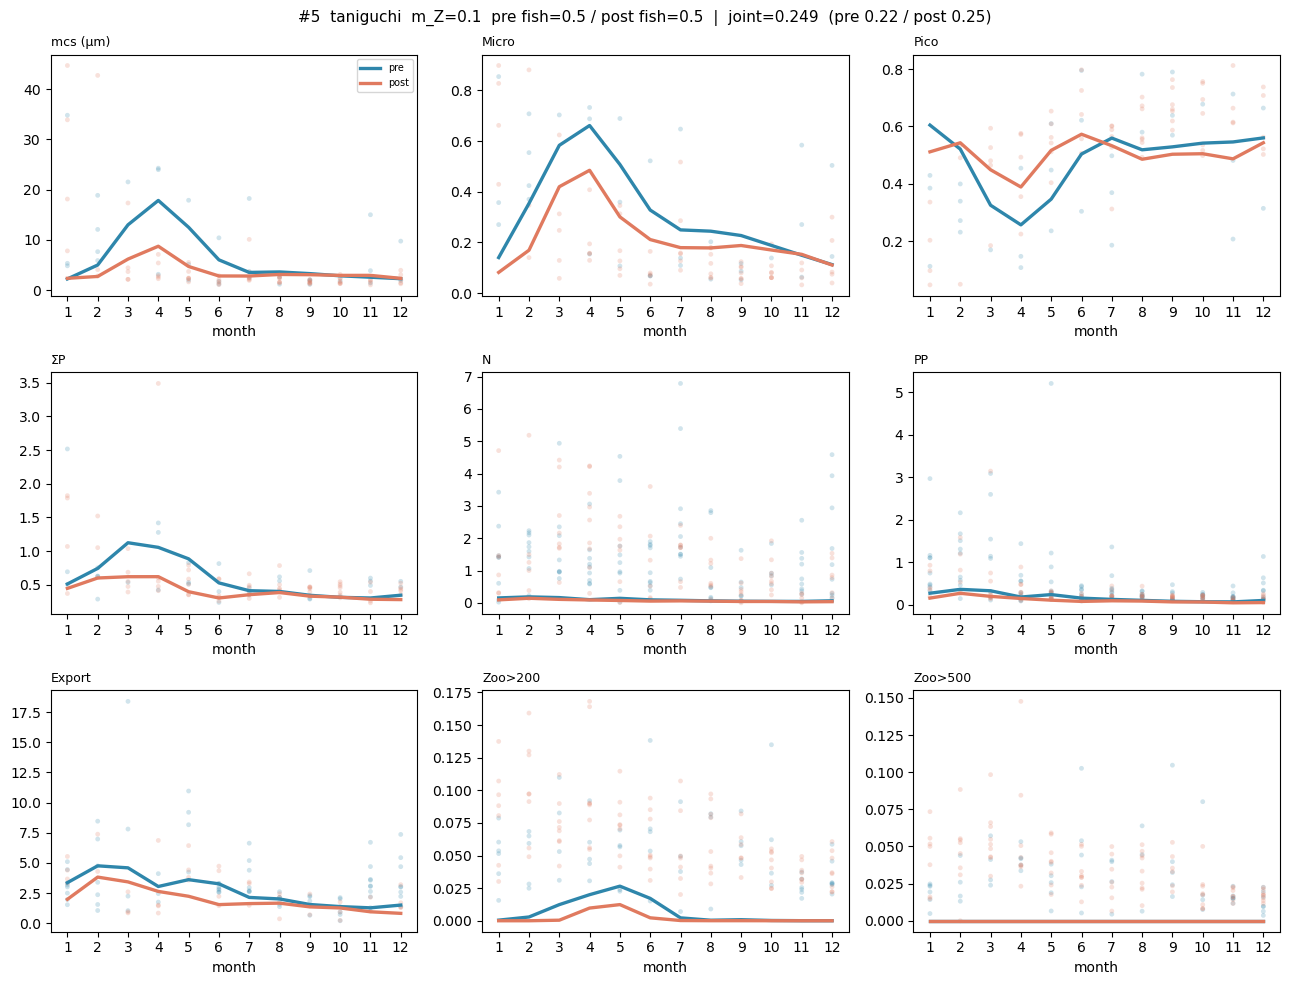

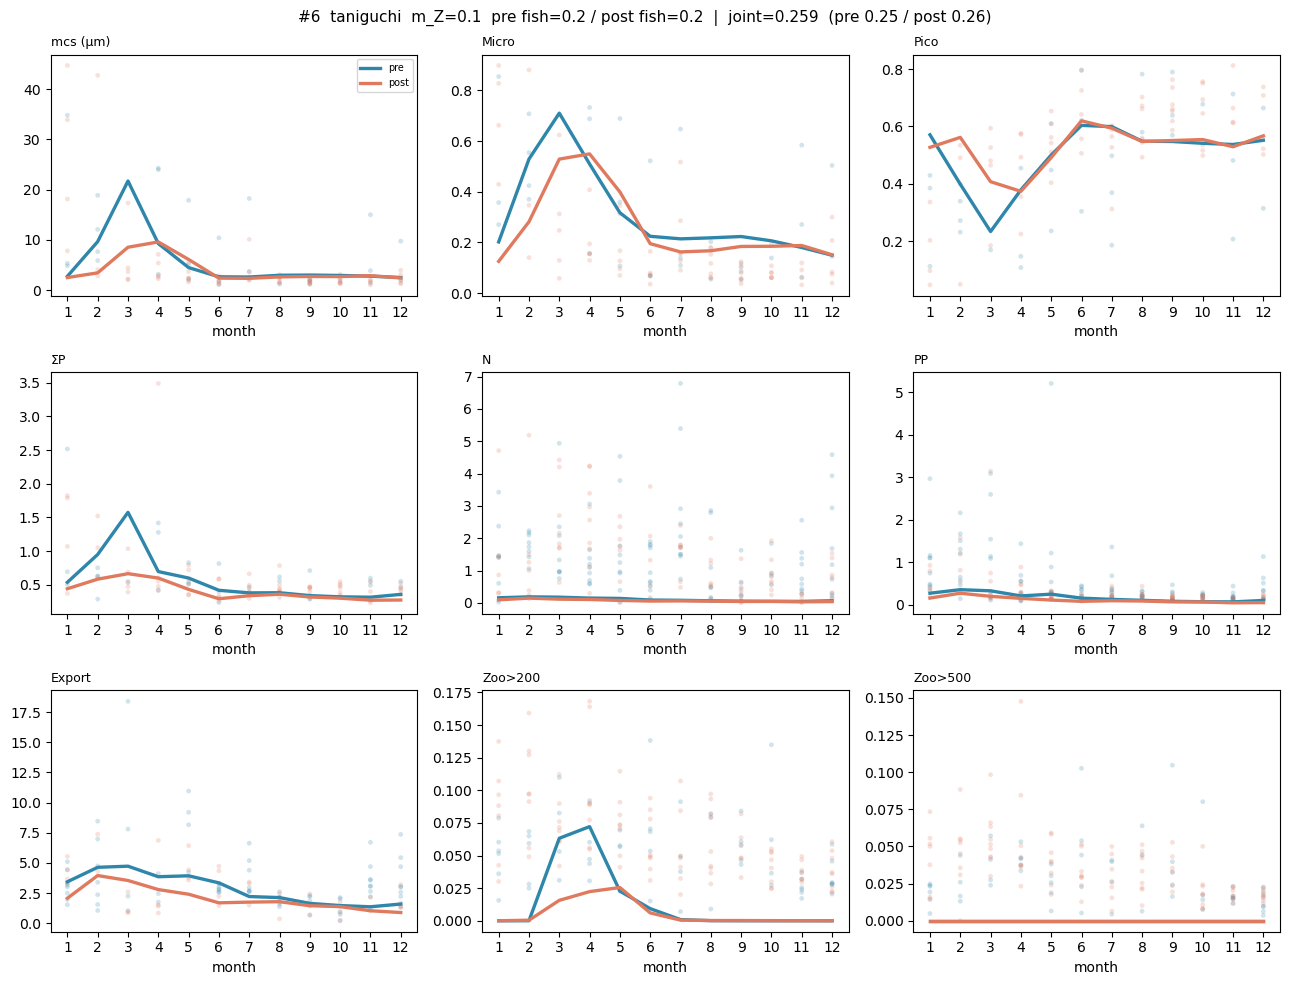

In [11]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt, seasonal_scan_harness as ssh
from cariaco_obs import DEFAULT_CSV_PATH
res = ssh.load_results('seasonal_scan_tune.pkl')
df  = res.df[~res.df.has_nan.astype(bool)].copy()
TOP_N = 6

# rank one-construct-both-eras joints (graded: post fish <= pre fish)
fishes = sorted(df.fish.unique()); joints=[]
for c in df.construct.unique():
  for mz in sorted(df.m_Z.unique()):
    for i,rp in enumerate(fishes):
      pr=df[(df.construct==c)&(df.m_Z==mz)&(df.group=='pre+recovery')&(df.fish==rp)]
      if not len(pr): continue
      for rq in fishes[:i+1]:
        po=df[(df.construct==c)&(df.m_Z==mz)&(df.group=='post')&(df.fish==rq)]
        if not len(po): continue
        joints.append(dict(cons=c,m_Z=mz,pre=rp,post=rq,
                           joint=max(pr.score.iloc[0],po.score.iloc[0]),
                           pre_sc=pr.score.iloc[0],post_sc=po.score.iloc[0]))
joints = sorted(joints,key=lambda x:x['joint'])[:TOP_N]

# obs (once)
GEOM=np.array([0.63,6.3,63.0]); binc=['pico_mmolN','nano_mmolN','micro_mmolN']
o=pd.read_csv(DEFAULT_CSV_PATH,parse_dates=['date'])
o['era3']=o['date'].dt.year.map(lambda y:'pre' if y<2005 else('post' if y<2014 else 'recovery')); o['mo']=o['date'].dt.month
GE={'pre+recovery':['pre','recovery'],'post':['post']}
def edf(g):
    e=o[o['era3'].isin(GE[g])].copy(); fb=e.dropna(subset=binc); tot=fb[binc].sum(1).values; fr=fb[binc].values/tot[:,None]
    e.loc[fb.index,'mcs']=10**(fr@np.log10(GEOM)); e.loc[fb.index,'sumP']=tot
    for i,b in enumerate(['pico','nano','micro']): e.loc[fb.index,b]=fr[:,i]
    return e
OBS={g:edf(g) for g in ['pre+recovery','post']}
def rec(cons,mz,group,fish):
    for r in res.records:
        if r['construct']==cons and r['group']==group and abs(r['fish']-fish)<1e-9 and abs(r['m_Z']-mz)<1e-9 and not r.get('has_nan'):
            return r
METRICS=[('mcs','mcs','mcs (µm)'),('micro','micro','Micro'),('pico','pico','Pico'),
         ('sumP','sumP','ΣP'),('N','NO3_mmolN','N'),('PP','PP_mmolN_m3_d','PP'),
         ('Export','export_flux_corrected_mmolN','Export'),('Z200','zoo_gt200_mmolN','Zoo>200'),
         ('Z500','zoo_gt500_mmolN','Zoo>500')]
ERAS=[('pre+recovery','pre','#2E86AB'),('post','post','#E07A5F')]

for n,J in enumerate(joints,1):
    recs={'pre+recovery':rec(J['cons'],J['m_Z'],'pre+recovery',J['pre']),
          'post':rec(J['cons'],J['m_Z'],'post',J['post'])}
    fig,axes=plt.subplots(3,3,figsize=(13,10))
    for ax,(k,col,lab) in zip(axes.flat,METRICS):
        for g,short,c in ERAS:
            e=OBS[g]
            if col in e.columns: ax.scatter(e['mo'],e[col],s=12,c=c,alpha=0.22,edgecolors='none')
            r=recs[g]
            if r is not None and 'clim_'+k in r:
                ax.plot(range(1,13),r['clim_'+k],'-',color=c,lw=2.4,zorder=5,label=short)
        ax.set_xticks(range(1,13)); ax.set_xlabel('month'); ax.set_title(lab,loc='left',fontsize=9)
    axes.flat[0].legend(fontsize=7)
    fig.suptitle(f"#{n}  {J['cons']}  m_Z={J['m_Z']}  pre fish={J['pre']} / post fish={J['post']}  "
                 f"|  joint={J['joint']:.3f}  (pre {J['pre_sc']:.2f} / post {J['post_sc']:.2f})",fontsize=11)
    fig.tight_layout(); plt.show()

[missing] pre+recovery fish=0.5


/var/folders/g_/s6xd0c9109v04q1j6n3spfh00000gn/T/ipykernel_12436/732851854.py:44: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout(); plt.show()


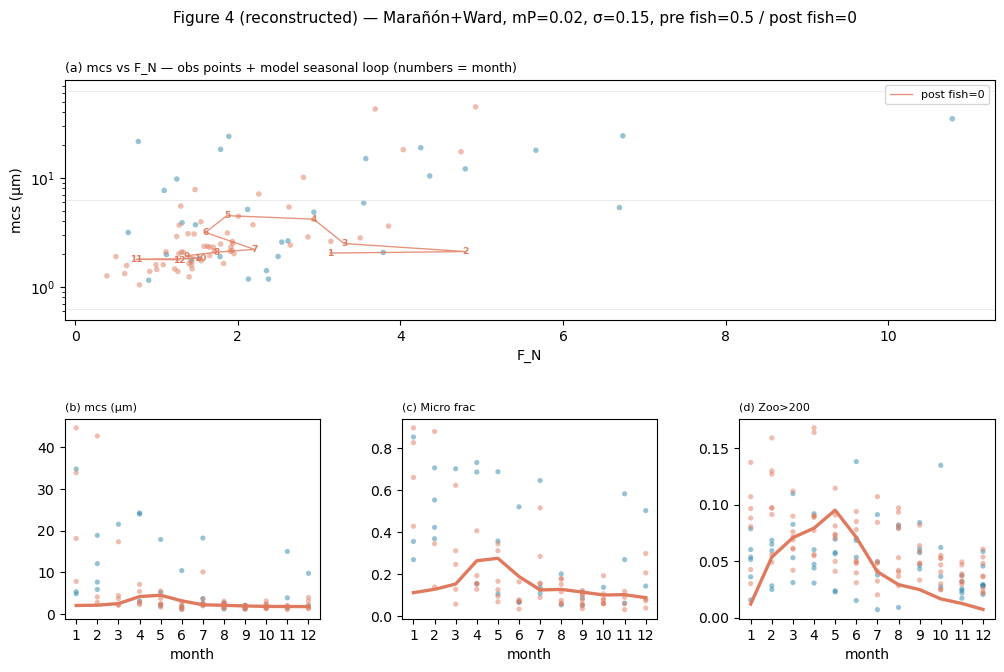

In [13]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt, seasonal_scan_harness as ssh
from cariaco_obs import DEFAULT_CSV_PATH
res = ssh.load_results('seasonal_scan_optimize.pkl')   # or 'seasonal_scan_tune.pkl' if that one's gone

WANT = {'mP':0.02, 'sigma_log':0.15, 'm_Z':0.1}        # all the Fig-4 defaults; checked only if present
ERAS = [('pre+recovery', 0.5, '#2E86AB'), ('post', 0.0, '#E07A5F')]
def rec(g, f):
    for r in res.records:
        if r['construct']!='maranon_ward' or r['group']!=g or abs(r['fish']-f)>1e-9 or r.get('has_nan'):
            continue
        if all(abs(r[k]-v)<1e-9 for k,v in WANT.items() if k in r):
            return r
    print(f"[missing] {g} fish={f}"); return None
RECS = {g: rec(g,f) for g,f,_ in ERAS}

GEOM=np.array([0.63,6.3,63.0]); binc=['pico_mmolN','nano_mmolN','micro_mmolN']; FN='FN_mmolN_m2_d'
o=pd.read_csv(DEFAULT_CSV_PATH,parse_dates=['date'])
o['era3']=o['date'].dt.year.map(lambda y:'pre' if y<2005 else('post' if y<2014 else 'recovery')); o['mo']=o['date'].dt.month
GE={'pre+recovery':['pre','recovery'],'post':['post']}
def edf(g):
    e=o[o['era3'].isin(GE[g])].copy(); fb=e.dropna(subset=binc); tot=fb[binc].sum(1).values; fr=fb[binc].values/tot[:,None]
    e.loc[fb.index,'mcs']=10**(fr@np.log10(GEOM)); e.loc[fb.index,'micro']=fr[:,2]; return e

fig=plt.figure(figsize=(12,7)); gs=fig.add_gridspec(2,3,height_ratios=[1.2,1],hspace=0.45,wspace=0.32)
axa=fig.add_subplot(gs[0,:])
for g,f,c in ERAS:
    e=edf(g); axa.scatter(e[FN],e['mcs'],s=16,c=c,alpha=0.5,edgecolors='none')
    r=RECS[g]
    if r is not None:
        fn=res.forcings[g]['fn']; axa.plot(fn,r['clim_mcs'],'-',color=c,lw=1.0,alpha=0.8,label=f'{g} fish={f:g}')
        for mi,(x,y) in enumerate(zip(fn,r['clim_mcs'])): axa.annotate(str(mi+1),(x,y),fontsize=6.5,color=c,ha='center',va='center',weight='bold')
for bg in GEOM: axa.axhline(bg,color='0.9',lw=0.6)
axa.set_yscale('log'); axa.set_xlabel('F_N'); axa.set_ylabel('mcs (µm)'); axa.legend(fontsize=8)
axa.set_title('(a) mcs vs F_N — obs points + model seasonal loop (numbers = month)',loc='left',fontsize=9)
for j,(k,col,lab) in enumerate([('mcs','mcs','mcs (µm)'),('micro','micro','Micro frac'),('Z200','zoo_gt200_mmolN','Zoo>200')]):
    ax=fig.add_subplot(gs[1,j])
    for g,f,c in ERAS:
        e=edf(g)
        if col in e.columns: ax.scatter(e['mo'],e[col],s=14,c=c,alpha=0.5,edgecolors='none')
        r=RECS[g]
        if r is not None: ax.plot(range(1,13),r['clim_'+k],'-',color=c,lw=2.4,zorder=5)
    ax.set_xticks(range(1,13)); ax.set_xlabel('month'); ax.set_title(f'({"bcd"[j]}) {lab}',loc='left',fontsize=8)
fig.suptitle('Figure 4 (reconstructed) — Marañón+Ward, mP=0.02, σ=0.15, pre fish=0.5 / post fish=0',fontsize=11)
fig.tight_layout(); plt.show()

running 2 × 60 yr ...


/Users/aoop/Documents/GitHub/xarray-simlab-ode/src/xso/core.py:148: UserWarning: Instability event triggered at t=1.832e+04 on P[28] = -0.00142. Run terminated, remaining time points NaN-padded. To loosen the safety threshold pass solver_kwargs={'instability_neg_threshold': -1e-3} to xso.setup; to disable, pass float('-inf').
  self.solver.solve(self.model, time_step)


pre+recovery (fish=0.5): ΣP nan cv nan | mcs nan | Z>200 pk nan/mn nan | Z>500 pk nan | max zoo ESD w/ biomass ~nan µm
post (fish=0.0): ΣP 0.52 cv 0.34 | mcs 2.34 | Z>200 pk 0.252/mn 0.026 | Z>500 pk 0.0297 | max zoo ESD w/ biomass ~579 µm


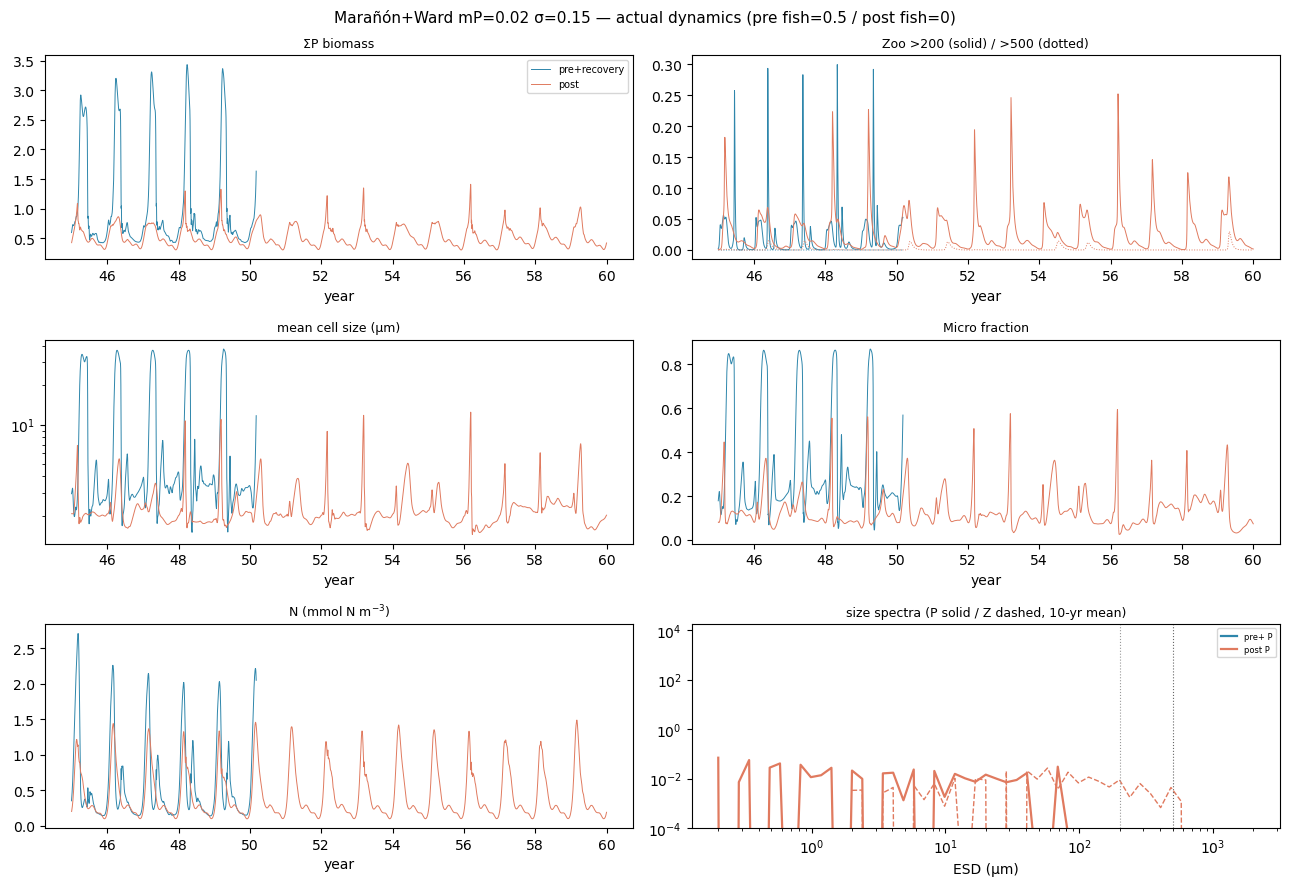

In [9]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt
import xso, parscan_utils_extended as pue
from cariaco_obs import DEFAULT_CSV_PATH
from baseline_r0_seasonal_setups import (model_baseline_seasonal, make_seasonal_input_vars,
                                         SLIM_OUTPUT_VARS, IVP_SOLVER_KWARGS)
from baseline_r0_setups import phyto_esd

YEARS = 60
SOLVER = {**IVP_SOLVER_KWARGS, 'instability_neg_threshold': -1e-3}
GEOM = np.array([0.63,6.3,63.0]); e = np.asarray(phyto_esd, float)
MU = np.where(e<=5.38, 0.33*e**0.57, 1.83*e**-0.45)    # Marañón 2013 growth
KS = 0.143*e**0.81                                      # Ward 2012 K_s

binc=['pico_mmolN','nano_mmolN','micro_mmolN']
df=pd.read_csv(DEFAULT_CSV_PATH,parse_dates=['date'])
df['era']=df['date'].dt.year.map(lambda y:'pre' if y<2005 else('post' if y<2014 else 'recovery')); df['mo']=df['date'].dt.month
def mm(eras,col):
    s=df[df['era'].isin(eras)].dropna(subset=[col]).groupby('mo')[col].mean().reindex(range(1,13))
    return s.interpolate(limit_direction='both').values
FOR={'pre+recovery':{k:mm(['pre','recovery'],c) for k,c in [('fn','FN_mmolN_m2_d'),('de','depth_cutoff'),('t','Temp_C')]},
     'post':{k:mm(['post'],c) for k,c in [('fn','FN_mmolN_m2_d'),('de','depth_cutoff'),('t','Temp_C')]}}
RUNS=[('pre+recovery',0.5,'#2E86AB'),('post',0.0,'#E07A5F')]

def run_full(forcing, fish):
    iv = make_seasonal_input_vars(forcing['fn'],forcing['de'],forcing['t'],fish_rate=fish,mu_max=MU,halfsat=KS)
    t = np.arange(0.0, YEARS*365.0+1.0, 1.0)
    setup = xso.setup(solver='solve_ivp', model=model_baseline_seasonal, time=t,
                      input_vars=iv, output_vars=SLIM_OUTPUT_VARS, solver_kwargs=SOLVER)
    out = pue.run_single_point(model_baseline_seasonal, setup, {})
    pb,zb=out['Phytoplankton__biomass'],out['Zooplankton__biomass']
    pdim=[d for d in pb.dims if d!='time'][0]; zdim=[d for d in zb.dims if d!='time'][0]
    pe,ze=out[pdim].values,out[zdim].values
    P=pb.transpose(pdim,'time').values; Z=zb.transpose(zdim,'time').values
    W=pue.compute_sieburth_weights(pe); bins=W@P; sb=bins.sum(0)
    fr=np.divide(bins,sb,out=np.full_like(bins,np.nan),where=sb>0)
    return dict(t=out['time'].values/365.0,P=P,Z=Z,pe=pe,ze=ze,mcs=10**(np.log10(GEOM)@fr),
                micro=fr[2],sumP=P.sum(0),sumZ=Z.sum(0),N=out['Nutrient__value'].values,
                Z200=Z[ze>200].sum(0),Z500=Z[ze>500].sum(0))

print("running 2 × 60 yr ...", flush=True)
R={g:run_full(FOR[g],f) for g,f,_ in RUNS}
for g,f,c in RUNS:
    r=R[g]; m=r['t']>=YEARS-15; zmean=r['Z'][:,-3650:].mean(1)
    zmax=r['ze'][zmean>1e-4].max() if (zmean>1e-4).any() else np.nan
    print(f"{g} (fish={f}): ΣP {r['sumP'][m].mean():.2f} cv {r['sumP'][m].std()/r['sumP'][m].mean():.2f} | "
          f"mcs {r['mcs'][m].mean():.2f} | Z>200 pk {r['Z200'][m].max():.3f}/mn {r['Z200'][m].mean():.3f} | "
          f"Z>500 pk {r['Z500'][m].max():.4f} | max zoo ESD w/ biomass ~{zmax:.0f} µm")

fig,ax=plt.subplots(3,2,figsize=(13,9))
for g,f,c in RUNS:
    r=R[g]; m=r['t']>=YEARS-15
    ax[0,0].plot(r['t'][m],r['sumP'][m],color=c,lw=0.7,label=g)
    ax[0,1].plot(r['t'][m],r['Z200'][m],color=c,lw=0.7); ax[0,1].plot(r['t'][m],r['Z500'][m],color=c,lw=0.7,ls=':')
    ax[1,0].plot(r['t'][m],r['mcs'][m],color=c,lw=0.7); ax[1,1].plot(r['t'][m],r['micro'][m],color=c,lw=0.7)
    ax[2,0].plot(r['t'][m],r['N'][m],color=c,lw=0.7)
    ax[2,1].plot(r['pe'],r['P'][:,-3650:].mean(1),color=c,lw=1.6,label=f'{g[:4]} P'); ax[2,1].plot(r['ze'],zmean if g=='post' else r['Z'][:,-3650:].mean(1),color=c,lw=1.0,ls='--')
ax[0,0].set_title('ΣP biomass',fontsize=9); ax[0,0].legend(fontsize=7)
ax[0,1].set_title('Zoo >200 (solid) / >500 (dotted)',fontsize=9)
ax[1,0].set_title('mean cell size (µm)',fontsize=9); ax[1,0].set_yscale('log')
ax[1,1].set_title('Micro fraction',fontsize=9); ax[2,0].set_title('N (mmol N m$^{-3}$)',fontsize=9)
ax[2,1].set_xscale('log'); ax[2,1].set_yscale('log'); ax[2,1].set_ylim(1e-4,None)
ax[2,1].axvline(200,color='0.6',ls=':',lw=0.8); ax[2,1].axvline(500,color='0.4',ls=':',lw=0.8)
ax[2,1].set_title('size spectra (P solid / Z dashed, 10-yr mean)',fontsize=9); ax[2,1].legend(fontsize=6)
for a in ax.flat: a.set_xlabel('year')
ax[2,1].set_xlabel('ESD (µm)')
fig.suptitle('Marañón+Ward mP=0.02 σ=0.15 — actual dynamics (pre fish=0.5 / post fish=0)',fontsize=11)
fig.tight_layout(); plt.show()

In [15]:
import seasonal_scan_harness as ssh, numpy as np, pandas as pd
res = ssh.load_results('seasonal_scan_optimize.pkl')
df = res.df[~res.df.has_nan.astype(bool)].copy()

PARAMS = ['KsZ', 'm_Z', 'sigma_log']        # what defines one construct + parameterisation
rows = []
for keys, gdf in df.groupby(['construct'] + PARAMS):
    pre  = gdf[gdf.group == 'pre+recovery'].set_index('fish')
    post = gdf[gdf.group == 'post'].set_index('fish')
    best = None
    for rp in pre.index:                     # graded: post fish <= pre fish
        for rq in post.index:
            if rq <= rp:
                j = max(pre.loc[rp, 'score'], post.loc[rq, 'score'])
                if best is None or j < best['joint']:
                    best = dict(joint=round(j, 3), pre_fish=rp, post_fish=rq,
                                pre_sc=round(pre.loc[rp, 'score'], 3),
                                post_sc=round(post.loc[rq, 'score'], 3),
                                pre_mcsmd=round(pre.loc[rp, 'mcs_med'], 2),
                                post_mcsmd=round(post.loc[rq, 'mcs_med'], 2),
                                pre_micromd=round(pre.loc[rp, 'micro_med'], 3),
                                post_micromd=round(post.loc[rq, 'micro_med'], 3))
    if best:
        best.update(dict(zip(['cons'] + PARAMS, keys)))
        rows.append(best)

J = pd.DataFrame(rows)[['cons'] + PARAMS + ['pre_fish', 'post_fish', 'joint',
        'pre_sc', 'post_sc', 'pre_mcsmd', 'post_mcsmd', 'pre_micromd', 'post_micromd']]
print("Best graded-r_F joint per (construct, KsZ, m_Z, sigma_log) — ONE construct, BOTH regimes")
print("obs median: pre mcs~4.8 micro~0.27 | post mcs~2.3 micro~0.13")
print(J.sort_values('joint').head(20).to_string(index=False))

Best graded-r_F joint per (construct, KsZ, m_Z, sigma_log) — ONE construct, BOTH regimes
obs median: pre mcs~4.8 micro~0.27 | post mcs~2.3 micro~0.13
        cons  KsZ  m_Z  sigma_log  pre_fish  post_fish  joint  pre_sc  post_sc  pre_mcsmd  post_mcsmd  pre_micromd  post_micromd
   taniguchi 0.35 0.10       0.20       0.4        0.1  0.239   0.239    0.193       3.23        2.37        0.241         0.159
   taniguchi 0.35 0.20       0.20       0.1        0.1  0.242   0.222    0.242       3.52        2.90        0.262         0.174
   taniguchi 0.35 0.20       0.15       0.1        0.1  0.259   0.259    0.232       3.70        2.76        0.242         0.144
   taniguchi 0.23 0.05       0.15       0.3        0.2  0.259   0.259    0.208       2.93        2.41        0.234         0.162
   taniguchi 0.23 0.10       0.15       0.2        0.2  0.261   0.241    0.261       3.01        2.68        0.233         0.186
maranon_ward 0.23 0.20       0.20       0.2        0.2  0.264   0.264    0.1

RANK 6/33: maranon_ward KsZ=0.23 m_Z=0.1 sigma=0.2 | pre_fish=0.3 / post_fish=0.1 | joint=0.273
re-running 2 × 60 yr ...


/var/folders/98/6c9k3fxx2hl5k0_928yjt7qw0000gn/T/ipykernel_57418/1364082663.py:47: Pandas4Warning: Starting with pandas version 4.0 all arguments of sum will be keyword-only.
  tot=o[binc].sum(1); fr=o[binc].div(tot.where(tot>0),axis=0); o['mcs']=10**(fr.values@np.log10(GEOM)); o['micro']=fr['micro_mmolN']; o['sumP']=tot


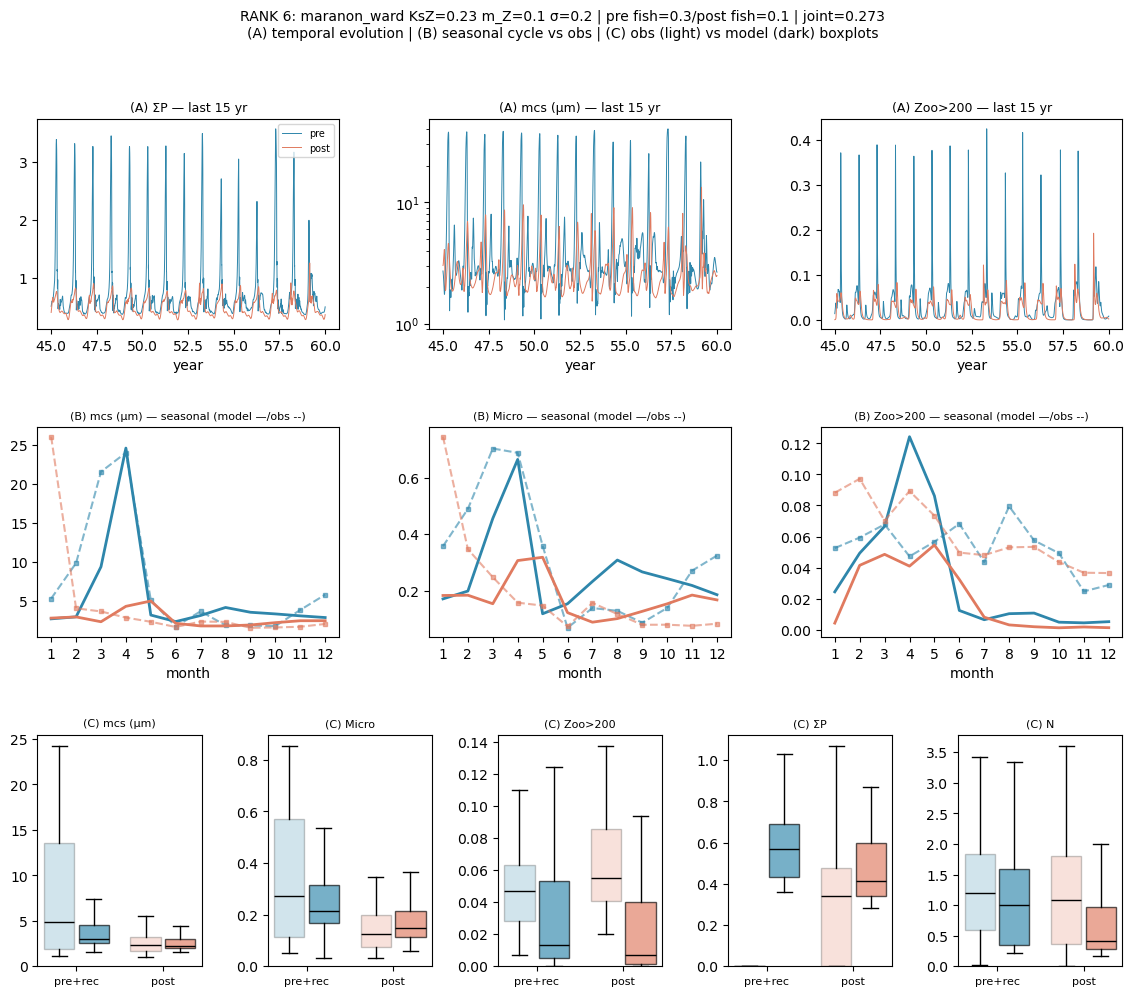

In [2]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt
import xso, parscan_utils_extended as pue, seasonal_scan_harness as ssh
from baseline_r0_seasonal_setups import model_baseline_seasonal, make_seasonal_input_vars, SLIM_OUTPUT_VARS
from cariaco_obs import DEFAULT_CSV_PATH

RANK = 6                                # <<< the only knob: which top-joint run to inspect
YEARS, SPINUP = 60, 15
GEOM = np.array([0.63,6.3,63.0]); binc=['pico_mmolN','nano_mmolN','micro_mmolN']
_MED = np.cumsum([31,28,31,30,31,30,31,31,30,31,30,31])

# --- rank the graded joints, pick RANK ---
res = ssh.load_results('seasonal_scan_optimize.pkl')
df = res.df[~res.df.has_nan.astype(bool)].copy(); P_=['KsZ','m_Z','sigma_log']; rows=[]
for keys,gd in df.groupby(['construct']+P_):
    pre=gd[gd.group=='pre+recovery'].set_index('fish'); po=gd[gd.group=='post'].set_index('fish'); best=None
    for rp in pre.index:
        for rq in po.index:
            if rq<=rp:
                j=max(pre.loc[rp,'score'],po.loc[rq,'score'])
                if best is None or j<best['joint']: best=dict(joint=j,pre_fish=rp,post_fish=rq)
    if best: best.update(dict(zip(['cons']+P_,keys))); rows.append(best)
J=pd.DataFrame(rows).sort_values('joint').reset_index(drop=True); s=J.iloc[RANK]
print(f"RANK {RANK}/{len(J)-1}: {s.cons} KsZ={s.KsZ} m_Z={s.m_Z} sigma={s.sigma_log} | "
      f"pre_fish={s.pre_fish} / post_fish={s.post_fish} | joint={s.joint:.3f}")

# --- re-run the selected config (full trajectory), both eras ---
CON=ssh.allometry(s.cons); FOR=ssh.build_forcings(['pre+recovery','post'])
def run_traj(f, fish):
    iv=make_seasonal_input_vars(f['fn'],f['de'],f['t'],fish_rate=float(fish),
            mu_max=CON['mu_max'],halfsat=CON['halfsat'],m_Z=float(s.m_Z))
    iv['Grazing'].update({'KsZ':float(s.KsZ),'sigma_log':float(s.sigma_log)})
    setup=xso.setup(solver='solve_ivp',model=model_baseline_seasonal,time=np.arange(0.,YEARS*365.+1.,1.),
                    input_vars=iv,output_vars=SLIM_OUTPUT_VARS,solver_kwargs=ssh.SEASONAL_SOLVER_KWARGS)
    out=pue.run_single_point(model_baseline_seasonal,setup,{})
    pb,zb=out['Phytoplankton__biomass'],out['Zooplankton__biomass']
    pdm,zdm=[d for d in pb.dims if d!='time'][0],[d for d in zb.dims if d!='time'][0]
    Pa=pb.transpose(pdm,'time').values; Za=zb.transpose(zdm,'time').values; ze=out[zdm].values
    W=pue.compute_sieburth_weights(out[pdm].values); b=W@Pa; sb=b.sum(0); fr=np.divide(b,sb,out=np.full_like(b,np.nan),where=sb>0)
    return dict(day=out['time'].values,mcs=10**(np.log10(GEOM)@fr),micro=fr[2],sumP=Pa.sum(0),
                N=out['Nutrient__value'].values,Z200=Za[ze>200].sum(0))
ERAS=[('pre+recovery',float(s.pre_fish),'#2E86AB'),('post',float(s.post_fish),'#E07A5F')]
print("re-running 2 × 60 yr ...",flush=True); R={g:run_traj(FOR[g],f) for g,f,_ in ERAS}

# --- obs ---
o=pd.read_csv(DEFAULT_CSV_PATH,parse_dates=['date'])
o['e3']=o['date'].dt.year.map(lambda y:'pre' if y<2005 else('post' if y<2014 else 'recovery')); o['mo']=o['date'].dt.month
tot=o[binc].sum(1); fr=o[binc].div(tot.where(tot>0),axis=0); o['mcs']=10**(fr.values@np.log10(GEOM)); o['micro']=fr['micro_mmolN']; o['sumP']=tot
GE={'pre+recovery':['pre','recovery'],'post':['post']}; OC={'mcs':'mcs','micro':'micro','Z200':'zoo_gt200_mmolN','N':'NO3_mmolN','sumP':'sumP'}
obs_box=lambda g,k: o[o['e3'].isin(GE[g])][OC[k]].dropna().values
obs_clim=lambda g,k: o[o['e3'].isin(GE[g])].dropna(subset=[OC[k]]).groupby('mo')[OC[k]].median().reindex(range(1,13)).values
def mclim(r,k):
    m=r['day']>=SPINUP*365; mo=np.clip(np.searchsorted(_MED,np.mod(r['day'][m],365),'right')+1,1,12); v=r[k][m]
    return np.array([np.nanmean(v[mo==i]) for i in range(1,13)])
def mbox(r,k):
    m=r['day']>=SPINUP*365; d=r['day'][m]; v=r[k][m]; mo=np.clip(np.searchsorted(_MED,np.mod(d,365),'right')+1,1,12)
    ym=(d//365).astype(int)*100+mo; return np.array([np.nanmean(v[ym==u]) for u in np.unique(ym)])

# --- figure: (A) temporal | (B) seasonal cycle vs obs | (C) obs-vs-model boxplots ---
fig=plt.figure(figsize=(14,11)); gs=fig.add_gridspec(3,1,height_ratios=[1,1,1.1],hspace=0.45)
gA=gs[0].subgridspec(1,3,wspace=0.3)
for j,(k,l) in enumerate([('sumP','ΣP'),('mcs','mcs (µm)'),('Z200','Zoo>200')]):
    ax=fig.add_subplot(gA[j])
    for g,f,c in ERAS:
        m=R[g]['day']>=(YEARS-15)*365; ax.plot(R[g]['day'][m]/365,R[g][k][m],color=c,lw=0.7,label=g.split('+')[0])
    ax.set_title(f'(A) {l} — last 15 yr',fontsize=9); ax.set_xlabel('year'); ax.set_yscale('log') if k=='mcs' else None
    if j==0: ax.legend(fontsize=7)
gB=gs[1].subgridspec(1,3,wspace=0.3)
for j,(k,l) in enumerate([('mcs','mcs (µm)'),('micro','Micro'),('Z200','Zoo>200')]):
    ax=fig.add_subplot(gB[j])
    for g,f,c in ERAS:
        ax.plot(range(1,13),mclim(R[g],k),'-',color=c,lw=2); ax.plot(range(1,13),obs_clim(g,k),'--s',color=c,ms=3,alpha=0.6)
    ax.set_title(f'(B) {l} — seasonal (model —/obs --)',fontsize=8); ax.set_xticks(range(1,13)); ax.set_xlabel('month')
gC=gs[2].subgridspec(1,5,wspace=0.4)
for j,(k,l) in enumerate([('mcs','mcs (µm)'),('micro','Micro'),('Z200','Zoo>200'),('sumP','ΣP'),('N','N')]):
    ax=fig.add_subplot(gC[j]); data=[]; pos=[]; cols=[]
    for i,(g,f,c) in enumerate(ERAS): data+=[obs_box(g,k),mbox(R[g],k)]; pos+=[i*2,i*2+0.8]; cols+=[c,c]
    bp=ax.boxplot(data,positions=pos,widths=0.7,patch_artist=True,showfliers=False,medianprops=dict(color='k'))
    for pch,c,mod in zip(bp['boxes'],cols,[0,1,0,1]): pch.set_facecolor(c); pch.set_alpha(0.65 if mod else 0.22)
    ax.set_xticks([0.4,2.4]); ax.set_xticklabels(['pre+rec','post'],fontsize=8); ax.set_title(f'(C) {l}',fontsize=8); ax.set_ylim(bottom=0)
fig.suptitle(f'RANK {RANK}: {s.cons} KsZ={s.KsZ} m_Z={s.m_Z} σ={s.sigma_log} | pre fish={s.pre_fish}/post fish={s.post_fish} | joint={s.joint:.3f}'
             f'\n(A) temporal evolution | (B) seasonal cycle vs obs | (C) obs (light) vs model (dark) boxplots',fontsize=10)
plt.show()

In [8]:
import numpy as np, xso, parscan_utils_extended as pue, seasonal_scan_harness as ssh
from baseline_r0_seasonal_setups import model_baseline_seasonal, make_seasonal_input_vars, SLIM_OUTPUT_VARS
from baseline_r0_setups import M_P

spec = ssh.allometry('maranon_ward')
F = ssh.build_forcings(['pre+recovery'])['pre+recovery']
FISH, MZ, KSZ, SIG = 0.3, 0.1, 0.23, 0.2

iv_traj = make_seasonal_input_vars(F['fn'], F['de'], F['t'], fish_rate=float(FISH),
            mu_max=spec['mu_max'], halfsat=spec['halfsat'], m_Z=float(MZ))                  # run_traj way
iv_traj['Grazing'].update({'KsZ': float(KSZ), 'sigma_log': float(SIG)})
iv_one  = make_seasonal_input_vars(F['fn'], F['de'], F['t'], fish_rate=FISH,
            mu_max=spec['mu_max'], halfsat=spec['halfsat'], mP=M_P, m_Z=MZ, spline_s=0.0)   # run_one way
iv_one['Grazing'].update({'KsZ': KSZ, 'sigma_log': SIG})

def eq(x, y):
    try: return np.allclose(np.asarray(x, float), np.asarray(y, float), equal_nan=True)
    except Exception: return x == y
nd = 0
for slot in sorted(set(iv_traj) | set(iv_one)):
    a, b = iv_one.get(slot, {}), iv_traj.get(slot, {})
    for k in sorted(set(a) | set(b)):
        if not eq(a.get(k), b.get(k)):
            nd += 1; print(f"DIFF {slot}.{k}: one={a.get(k)!r} traj={b.get(k)!r}")
print(f"iv diff: {nd} fields" + (" -> setups identical" if nd == 0 else ""))

def run(iv, tag):
    setup = xso.setup(solver='solve_ivp', model=model_baseline_seasonal,
                      time=np.arange(0., 60*365.+1., 1.), input_vars=iv,
                      output_vars=SLIM_OUTPUT_VARS, solver_kwargs=ssh.SEASONAL_SOLVER_KWARGS)
    out = pue.run_single_point(model_baseline_seasonal, setup, {})
    print(f"  {tag}: nan_frac={float(np.isnan(out['Nutrient__value'].values).mean()):.2f}")

run(iv_traj, 'run_traj-style (multi-thread)')
run(iv_one,  'run_one-style  (multi-thread)')
try:
    from threadpoolctl import threadpool_limits, threadpool_info
    print("BLAS now:", [(i['internal_api'], i['num_threads']) for i in threadpool_info()])
    with threadpool_limits(limits=1):
        run(iv_one, 'run_one-style  (1 BLAS thread)')
except ImportError:
    print("pip install threadpoolctl  # to test the 1-thread hypothesis")

iv diff: 0 fields -> setups identical
  run_traj-style (multi-thread): nan_frac=0.00
  run_one-style  (multi-thread): nan_frac=0.00
pip install threadpoolctl  # to test the 1-thread hypothesis


In [6]:
np.isnan(R['pre+recovery']['mcs'][15*365:]).mean()

np.float64(0.0)

In [7]:
import numpy as np
res = ssh.load_results('seasonal_scan_optimize.pkl')
d = res.df

# (1) what did the SCAN actually record for this exact config?
sel = d[(d.construct == 'maranon_ward') & (d.group == 'pre+recovery') & np.isclose(d.fish, 0.3)
        & np.isclose(d.KsZ, 0.23) & np.isclose(d.m_Z, 0.1) & np.isclose(d.sigma_log, 0.2)]
print("scan record:", sel[['has_nan', 'mcs', 'mcs_med', 'score', 'Z200_peak', 'mcs_conv']].to_string(index=False))

# (2) does the pkl's forcing differ from CURRENT build_forcings?
fp = res.forcings['pre+recovery']
fc = ssh.build_forcings(['pre+recovery'])['pre+recovery']
for k in ('fn', 'de', 't'):
    print(f"forcing {k}: max|pkl - current| = {np.max(np.abs(np.asarray(fp[k]) - np.asarray(fc[k]))):.4g}")

# (3) re-run run_one with the PKL forcing vs current forcing -> does stability return?
spec = ssh.allometry('maranon_ward')
for tag, F in [('PKL', fp), ('CUR', fc)]:
    c = ssh.run_one(spec, F, fish_rate=0.3, years=60, spinup=15, m_Z=0.1,
                    grazing={'KsZ': 0.23, 'sigma_log': 0.2})
    print(f"pre+rec fish0.3 {tag}-forcing: has_nan={c['has_nan']} mcs={c.get('mcs', float('nan')):.2f}")

scan record:  has_nan     mcs  mcs_med    score  Z200_peak  mcs_conv
   False 5.55292 2.915179 0.273363    0.11977  1.013275
forcing fn: max|pkl - current| = 0
forcing de: max|pkl - current| = 0
forcing t: max|pkl - current| = 0
pre+rec fish0.3 PKL-forcing: has_nan=False mcs=5.53
pre+rec fish0.3 CUR-forcing: has_nan=False mcs=5.53


In [3]:
import os, time
for v in ("OMP_NUM_THREADS", "OPENBLAS_NUM_THREADS", "MKL_NUM_THREADS", "VECLIB_MAXIMUM_THREADS"):
    os.environ.setdefault(v, "1")          # pins the spawned workers (they inherit env)

from multiprocessing import Pool
import seasonal_scan_harness as ssh

YEARS, SPINUP, PROCS = 10, 3, 6
N = 2 * PROCS                               # 12 combos -> ~2 per worker, shows amortisation
forcings   = ssh.build_forcings()
constructs = [ssh.allometry(c) for c in ssh.DEFAULT_CONSTRUCTS]
groups     = list(forcings)
combos = [(constructs[i % len(constructs)], forcings[groups[i % len(groups)]],
           0.0, YEARS, SPINUP) for i in range(N)]

t0 = time.perf_counter()
for c in combos:
    ssh.run_one(*c)
t_serial = time.perf_counter() - t0

t0 = time.perf_counter()
with Pool(PROCS) as p:
    p.starmap(ssh.run_one, combos)
t_pool = time.perf_counter() - t0

print(f"serial {t_serial:.1f}s | pool {t_pool:.1f}s | speedup {t_serial/t_pool:.1f}x (ideal ~{PROCS}x)")

serial 457.0s | pool 115.4s | speedup 4.0x (ideal ~6x)


In [3]:
import time, multiprocessing as mp
from mini_xso_model import run_point

PROCS, N, MAX_STEP = 6, 12, 0.02
args = [(0.6 + 0.05*i, 400.0, 0.1, MAX_STEP) for i in range(N)]

t0 = time.perf_counter(); [run_point(*a) for a in args]; ts = time.perf_counter()-t0
t0 = time.perf_counter()
with mp.get_context("spawn").Pool(PROCS) as p:
    p.starmap(run_point, args)
tp = time.perf_counter()-t0
print(f"serial {ts:.2f}s | pool {tp:.2f}s | speedup {ts/tp:.1f}x")

serial 72.37s | pool 13.59s | speedup 5.3x
